# Pavement Crack Detection using Semantic Segmentation

by Mary

In [1]:
!rm -rf /root/.cache/torch

In [ ]:
!pip install segmentation-models-pytorch

In [3]:
import shutil
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import zipfile
import cv2
import random
import xml.etree.ElementTree as ET
import argparse
import segmentation_models_pytorch as smp
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [4]:
from IPython.display import Image, display
import copy

**Введение**

  В данном проекте вам предстоит реализовать систему машинного зрения для детектирования дефектов дорожного полотна с помощью семантической сегментационной модели. При работе с данным проектом вы научитесь обучать нейронные сети, осуществлять их инференс, делать оценку работы детектора, а также использовать Docker.

  Материалы

**Датасеты:**

·	Craсck 500


**Статьи:**
	https://arxiv.org/abs/1901.06340

**Архитектуры нейронных сетей:**

*  Unet
*  Unet++
* DeepLabV3
* FPN


**Задание №1**

В данном задании вам предстоит обучить сегментационную модель на ваш выбор. Выше приведены четыре модели, вам необходимо определить внутри команды, кто и какую модель будет обучать. Ваша главная задача – обучить выбранную модель на одном и том же датасете, а затем сравнить результаты, получившиеся у вас и у остальных членов команды.

Для обучения нейронной сети воспользуйтесь библиотекой Segmentation Models. Там вышеприведенные архитектуры есть. Вы также можете не ограничиваться только этими архитектурами и упомянутой библиотекой – можете предложить и другую модель на свой выбор. Просьба аргументировать свой выбор и описать в таком случае, почему вы решили выбрать другую модель.


Я выбираю архитектуру Unet++

После просмотра данных можно заметить, что у нас трещины разной глубины, длины и ширины. Есть менее заметные трещинки, а есть глобальные повреждения, нам нужно распознавать и те, и другие максимально качетсвенно.

Датасет у нас довольно небольшой(по кр мере не гигантский) - 1896 изображений и соответствующих масок в трейне.

Теперь основные характеристики UNET++

*	Nested skip-соединения: Они помогают модели глубже агрегировать информацию с разных уровней, что позволяет точнее выделять тонкие, почти незаметные трещинки на дороге.
Эффект:

  Сокращает семантический разрыв между низкоуровневыми (границы) и высокоуровневыми (контекст) признаками.

  Улучшает передачу информации от энкодера к декодеру, минимизируя потерю деталей.

*	Высокая точность: U-Net++ часто показывает лучшие результаты, чем стандартный U-Net, именно благодаря своим более сложным путям передачи признаков. Это важно, когда нужно не просто найти дефект, а сделать это максимально аккуратно. показывает стабильную работу. (и ресурсоёмкость оправдана)

  Deep Supervision
  Механизм: Лосс-функция вычисляется не только на выходе сети, но и на промежуточных слоях декодера

  Dense-блоки для семантического согласования
  Реализация: Вместо прямой конкатенации признаков кодировщика и декодера используются dense-блоки — свёрточные слои, объединяющие признаки из всех предыдущих уровней =>  улучшенное выделение границ объектов и устойчивость к шуму

*	Подходит для небольших датасетов: В нашем Crack500 даже если данных не так много, U-Net++ справляется, хорошо обучается на ограниченном объёме и

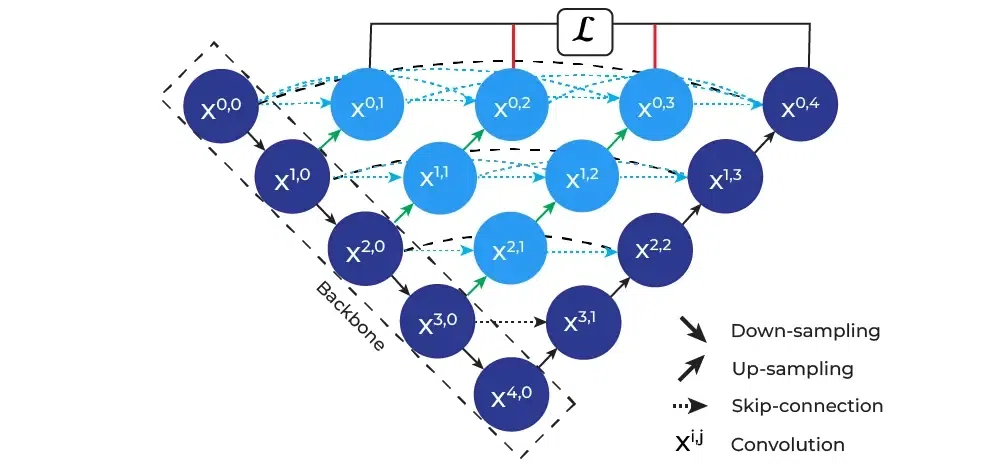

У UNet++ есть 3 дополнения к оригинальному U-Net:

* redesigned skip pathways (изображены зелёным на картинке ниже)
* dense skip connections (изображены голубым на картинке ниже)
* deep supervision (изображены красным на картинке ниже)

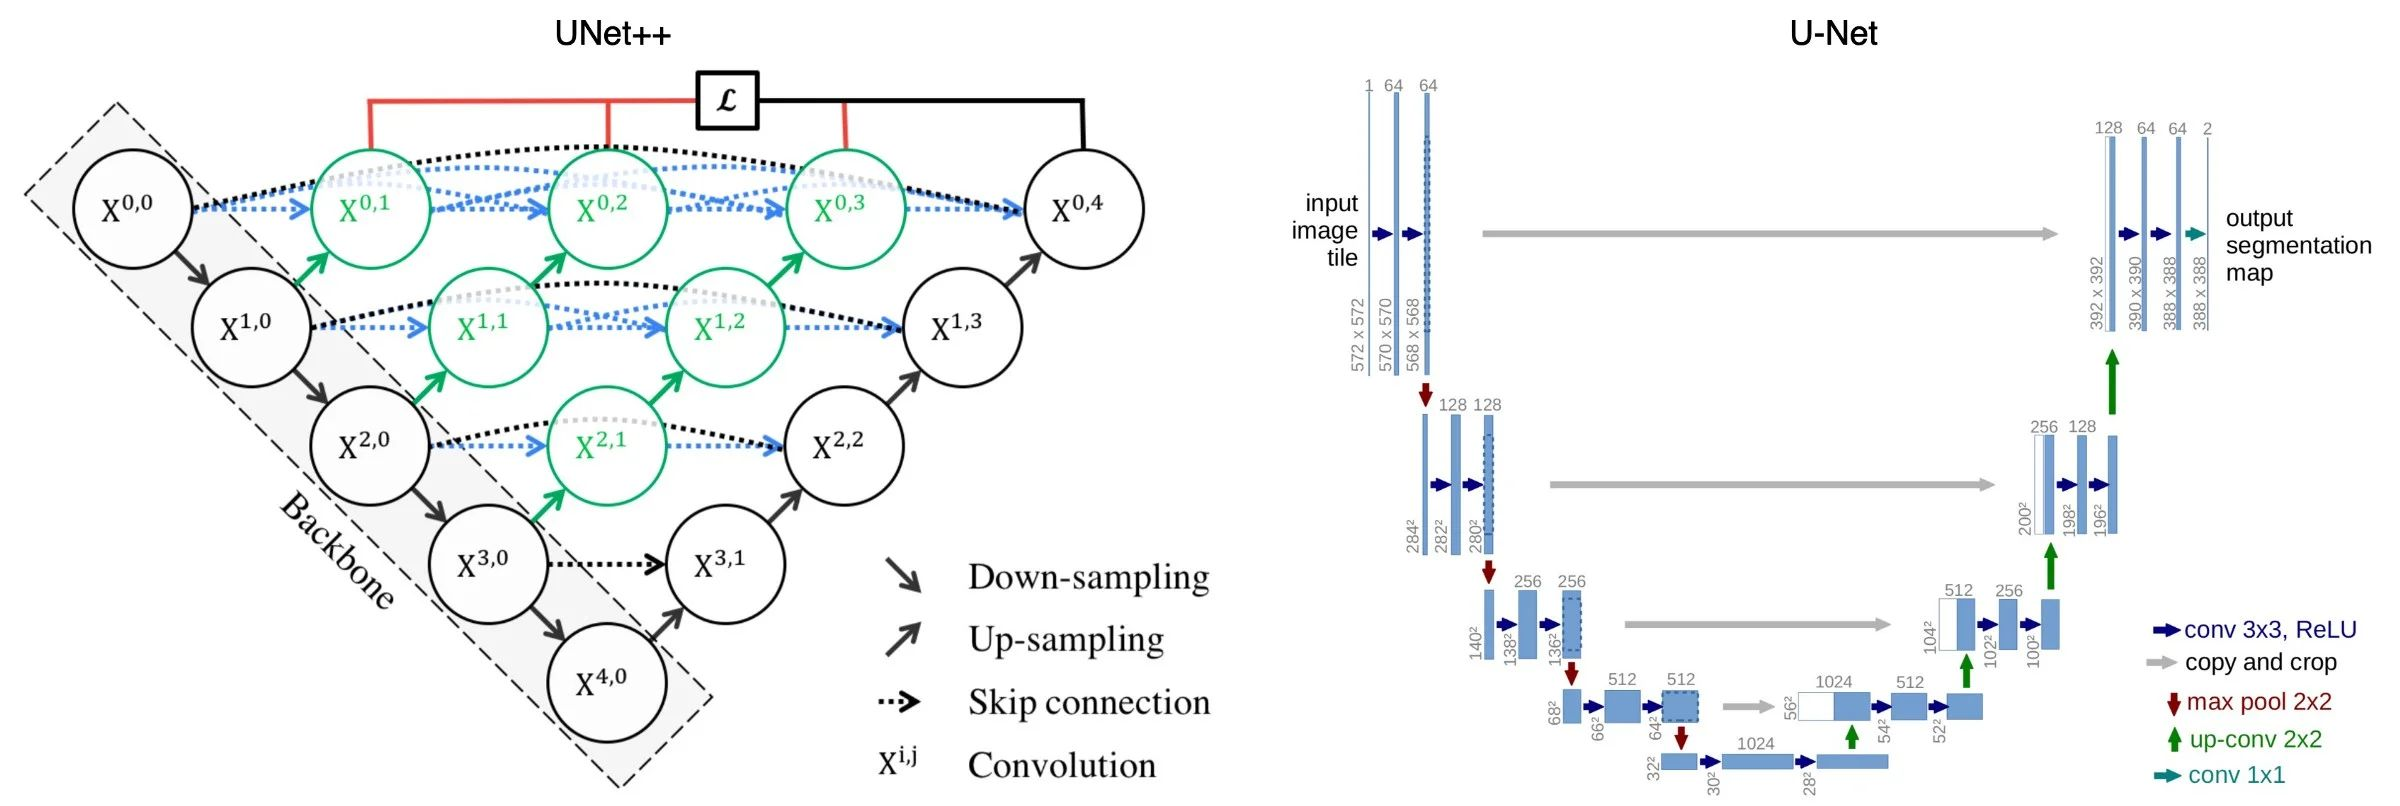

В целом, U-Net++ является универсальной и эффективной архитектурой для задач сегментации изображений, особенно когда требуется детальная и точная сегментация объектов с сложной структурой

In [5]:
running_in_colab = "COLAB_GPU" in os.environ

In [6]:
if running_in_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    common_path = "/content/drive/MyDrive/Colab Notebooks/Task2/"  # путь для Colab
else:
    common_path = "/app/Task2/"  # путь для Docker/локальный запуск

Mounted at /content/drive


In [7]:
print("Common path set to:", common_path)

Common path set to: /content/drive/MyDrive/Colab Notebooks/Task2/


In [8]:
dataset_path = os.path.join(common_path, "CRACK500")

In [ ]:
for file in os.listdir(dataset_path):
    if file.lower().endswith(".zip"):
        zip_path = os.path.join(dataset_path, file)
        extract_folder = os.path.join(dataset_path, file[:-4])
        if not os.path.exists(extract_folder):
            print("Extracting", file, "to", extract_folder)
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(extract_folder)
        else:
            print(f"{extract_folder} уже существует, пропускаем распаковку.")

In [9]:
print(os.listdir(dataset_path))

['valcrop.zip', 'traincrop.zip', 'fphb_testresult.zip', 'testdata.zip', 'valdata.zip', 'test.txt', 'train.txt', 'val.txt', 'testcrop.zip', '.DS_Store', 'traincrop', 'valcrop', 'testdata', 'valdata', 'testcrop', 'fphb_testresult']


In [10]:
dest_base = os.path.join(common_path, "data")
train_images_dest = os.path.join(dest_base, "train", "images")
train_masks_dest  = os.path.join(dest_base, "train", "masks")
val_images_dest   = os.path.join(dest_base, "val", "images")
val_masks_dest    = os.path.join(dest_base, "val", "masks")
test_images_dest  = os.path.join(dest_base, "test", "images")
test_masks_dest   = os.path.join(dest_base, "test", "masks")

In [ ]:
for folder in [train_images_dest, train_masks_dest, val_images_dest, val_masks_dest, test_images_dest, test_masks_dest]:
    os.makedirs(folder, exist_ok=True)

In [ ]:
def read_file_list(txt_file):
    with open(txt_file, 'r') as f:
        lines = f.read().splitlines()
    return [line.strip() for line in lines if line.strip()]

In [ ]:
train_txt = os.path.join(dataset_path, "train.txt")
val_txt   = os.path.join(dataset_path, "val.txt")
test_txt  = os.path.join(dataset_path, "test.txt")

In [ ]:
train_list = read_file_list(train_txt) if os.path.exists(train_txt) else []
val_list   = read_file_list(val_txt)   if os.path.exists(val_txt)   else []
test_list  = read_file_list(test_txt)  if os.path.exists(test_txt)  else []

In [ ]:
print("Number of training entries:", len(train_list))
print("Number of validation entries:", len(val_list))
print("Number of test entries:", len(test_list))

Number of training entries: 1896
Number of validation entries: 348
Number of test entries: 1124


In [ ]:
def adjust_base_folder(base_folder):
    nested = os.path.join(base_folder, os.path.basename(base_folder))
    if os.path.isdir(nested):
        print(f"Найден вложенный каталог {os.path.basename(base_folder)} внутри {base_folder}. Используем его как базовый.")
        return nested
    return base_folder

In [ ]:
train_base = os.path.join(dataset_path, "traincrop")
if os.path.exists(os.path.join(dataset_path, "valcrop")):
    val_base = os.path.join(dataset_path, "valcrop")
elif os.path.exists(os.path.join(dataset_path, "valdata")):
    val_base = os.path.join(dataset_path, "valdata")
else:
    val_base = None

In [ ]:
if os.path.exists(os.path.join(dataset_path, "testcrop")):
    test_base = os.path.join(dataset_path, "testcrop")
elif os.path.exists(os.path.join(dataset_path, "testdata")):
    test_base = os.path.join(dataset_path, "testdata")
else:
    test_base = None

In [ ]:
train_base = adjust_base_folder(train_base)
if val_base:
    val_base = adjust_base_folder(val_base)
if test_base:
    test_base = adjust_base_folder(test_base)

Найден вложенный каталог valcrop внутри /content/drive/MyDrive/Colab Notebooks/Task2/CRACK500/valcrop. Используем его как базовый.
Найден вложенный каталог testcrop внутри /content/drive/MyDrive/Colab Notebooks/Task2/CRACK500/testcrop. Используем его как базовый.


In [ ]:
print("Train base folder:", train_base)
print("Validation base folder:", val_base)
print("Test base folder:", test_base)

Train base folder: /content/drive/MyDrive/Colab Notebooks/Task2/CRACK500/traincrop
Validation base folder: /content/drive/MyDrive/Colab Notebooks/Task2/CRACK500/valcrop/valcrop
Test base folder: /content/drive/MyDrive/Colab Notebooks/Task2/CRACK500/testcrop/testcrop


In [ ]:
def find_file_case_insensitive(folder, filename):
    for f in os.listdir(folder):
        if f.lower() == filename.lower():
            return os.path.join(folder, f)
    return None

In [ ]:
def process_entries(entries, base_folder, dest_img_dir, dest_mask_dir):
    if base_folder is None:
        print("Base folder отсутствует, пропускаем обработку записей.")
        return
    prefix = os.path.basename(base_folder) + "/"
    for line in entries:
        parts = line.split()
        if len(parts) < 2:
            print("Неверная строка (нет двух путей):", line)
            continue
        img_rel, mask_rel = parts[0], parts[1]
        if img_rel.startswith(prefix):
            img_rel = img_rel[len(prefix):]
        if mask_rel.startswith(prefix):
            mask_rel = mask_rel[len(prefix):]
        img_src = os.path.join(base_folder, img_rel)
        mask_src = os.path.join(base_folder, mask_rel)
        if not os.path.exists(img_src):
            alt_img_src = find_file_case_insensitive(base_folder, os.path.basename(img_rel))
            if alt_img_src:
                img_src = alt_img_src
            else:
                print("Image file not found:", img_src)
                continue
        if not os.path.exists(mask_src):
            alt_mask_src = find_file_case_insensitive(base_folder, os.path.basename(mask_rel))
            if alt_mask_src:
                mask_src = alt_mask_src
            else:
                print("Mask file not found:", mask_src)
                continue
        shutil.copy(img_src, dest_img_dir)
        shutil.copy(mask_src, dest_mask_dir)

In [ ]:
print("Processing training entries...")
process_entries(train_list, train_base, train_images_dest, train_masks_dest)
print("Processing validation entries...")
process_entries(val_list, val_base, val_images_dest, val_masks_dest)
print("Processing test entries...")
process_entries(test_list, test_base, test_images_dest, test_masks_dest)

Processing training entries...
Processing validation entries...
Processing test entries...


In [ ]:
print("Примеры файлов в train/images:", os.listdir(train_images_dest)[:5])
print("Примеры файлов в train/masks:", os.listdir(train_masks_dest)[:5])
if val_base:
    print("Примеры файлов в val/images:", os.listdir(val_images_dest)[:5])
    print("Примеры файлов в val/masks:", os.listdir(val_masks_dest)[:5])
if test_base:
    print("Примеры файлов в test/images:", os.listdir(test_images_dest)[:5])
    print("Примеры файлов в test/masks:", os.listdir(test_masks_dest)[:5])

Примеры файлов в train/images: ['20160222_081011_1281_721.jpg', '20160222_081011_1921_721.jpg', '20160222_081011_1_361.jpg', '20160222_081011_1_721.jpg', '20160222_081011_641_361.jpg']
Примеры файлов в train/masks: ['20160222_081011_1281_721.png', '20160222_081011_1921_721.png', '20160222_081011_1_361.png', '20160222_081011_1_721.png', '20160222_081011_641_361.png']
Примеры файлов в val/images: ['20160222_080850_1281_361.jpg', '20160222_080850_1281_721.jpg', '20160222_080850_1921_1.jpg', '20160222_080850_1921_361.jpg', '20160222_080850_1_361.jpg']
Примеры файлов в val/masks: ['20160222_080850_1281_361.png', '20160222_080850_1281_721.png', '20160222_080850_1921_1.png', '20160222_080850_1921_361.png', '20160222_080850_1_361.png']
Примеры файлов в test/images: ['20160222_080933_361_1.jpg', '20160222_080933_361_1281.jpg', '20160222_080933_361_1921.jpg', '20160222_080933_361_641.jpg', '20160222_080933_721_1.jpg']
Примеры файлов в test/masks: ['20160222_080933_361_1.png', '20160222_080933_36

# EDA

In [ ]:
print("Train images path:", train_images_dest)
print("Train masks path:", train_masks_dest)

Train images path: /content/drive/MyDrive/Colab Notebooks/Task2/data/train/images
Train masks path: /content/drive/MyDrive/Colab Notebooks/Task2/data/train/masks


In [ ]:
train_img_files = os.listdir(train_images_dest)
train_mask_files = os.listdir(train_masks_dest)
print("Number of train images:", len(train_img_files))
print("Number of train masks:", len(train_mask_files))

Number of train images: 1896
Number of train masks: 1896


In [ ]:
sample_img_path = os.path.join(train_images_dest, train_img_files[0])
sample_mask_path = os.path.join(train_masks_dest, train_mask_files[0])

In [ ]:
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

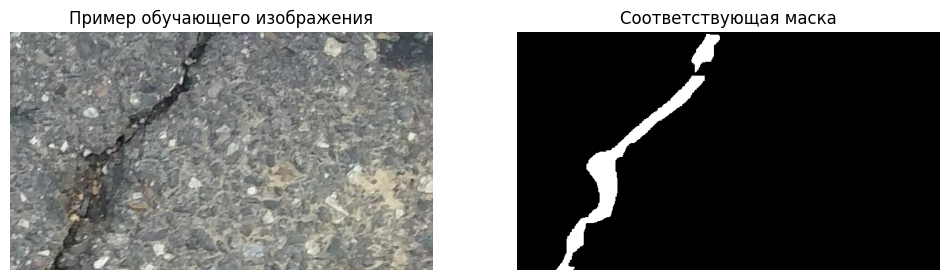

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Пример обучающего изображения")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(sample_mask, cmap='gray')
plt.title("Соответствующая маска")
plt.axis("off")
plt.show()

Примеры визуализации показывают, что маски соответствуют изображениям, и контуры трещин хорошо видны.

## Оценка сбалансированности классов в обучающих масках

Предположим, что в масках фон = 0, а трещина = 1 (если маски в формате 0/255, делим на 255)

In [ ]:
pixel_counts = {0: 0, 1: 0}

In [ ]:
for mask_file in train_mask_files:
    mask_path = os.path.join(train_masks_dest, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    unique_vals = np.unique(mask)
    if 255 in unique_vals:
        mask = mask // 255  # 255 -> 1, 0 -> 0
    counts = np.bincount(mask.flatten(), minlength=2)
    pixel_counts[0] += counts[0]
    pixel_counts[1] += counts[1]

In [ ]:
print("Общее количество пикселей по классам в обучающих масках:")
print("Фон (0):", pixel_counts[0])
print("Трещина (1):", pixel_counts[1])

Общее количество пикселей по классам в обучающих масках:
Фон (0): 413534276
Трещина (1): 27965116


In [ ]:
labels = ['Фон', 'Трещина']
sizes = [pixel_counts[0], pixel_counts[1]]

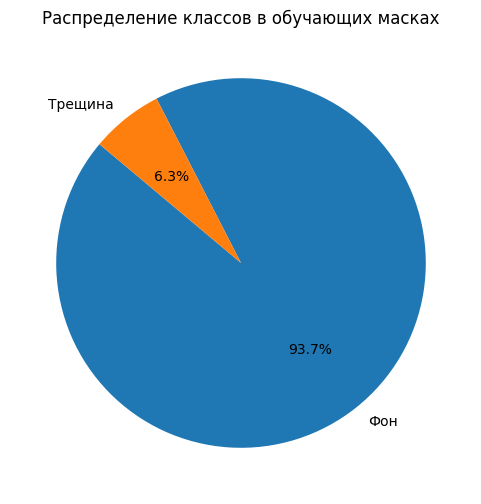

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Распределение классов в обучающих масках")
plt.show()

Подсчёт пикселей по классам показывает, что фон (0) занимает 93,7% пикселей, а трещина  (1) – примерно 6,3%.
Такой сильный дисбаланс (фон доминирует- ожидаемо 😁) - характерная проблема для задач сегментации, где мелкие дефекты могут быть «затеряны» в общем количестве фоновых пикселей

## Анализ размера трещин

In [ ]:
all_areas = []

In [ ]:
for mask_file in train_mask_files:
    mask_path = os.path.join(train_masks_dest, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if 255 in np.unique(mask):
        mask = mask // 255
    num_labels, labels_im = cv2.connectedComponents(mask.astype(np.uint8))
    for label in range(1, num_labels):
        area = np.sum(labels_im == label)
        all_areas.append(area)

In [ ]:
print("Средняя площадь трещин:", np.mean(all_areas))
print("Максимальная площадь трещины:", np.max(all_areas))
print("Минимальная площадь трещины:", np.min(all_areas))

Средняя площадь трещин: 6580.027294117647
Максимальная площадь трещины: 96649
Минимальная площадь трещины: 1


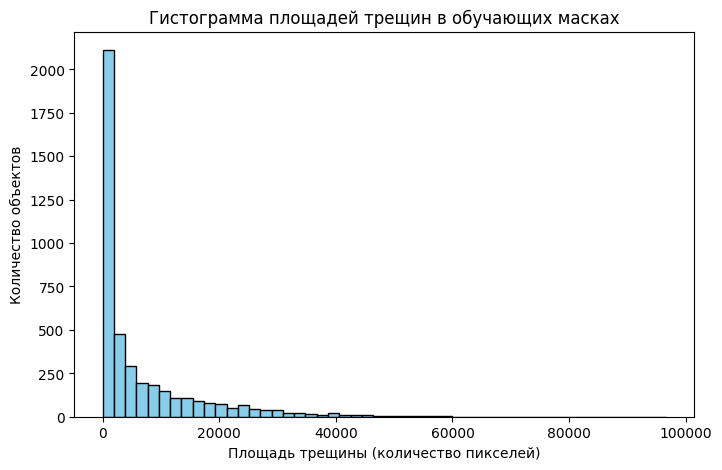

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(all_areas, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Площадь трещины (количество пикселей)")
plt.ylabel("Количество объектов")
plt.title("Гистограмма площадей трещин в обучающих масках")
plt.show()

Видим довольно широкое распределение размеров трещин, но кол-во падает с размером, это может влиять на обучение модели, возможно поможет выбирать функцию потерь или например аугметнации

In [ ]:
def draw_contours_on_mask(mask):
    mask_bin = (mask > 0).astype(np.uint8)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_contours = cv2.cvtColor(mask_bin * 255, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(mask_contours, contours, -1, (0, 0, 255), 2)
    return mask_contours

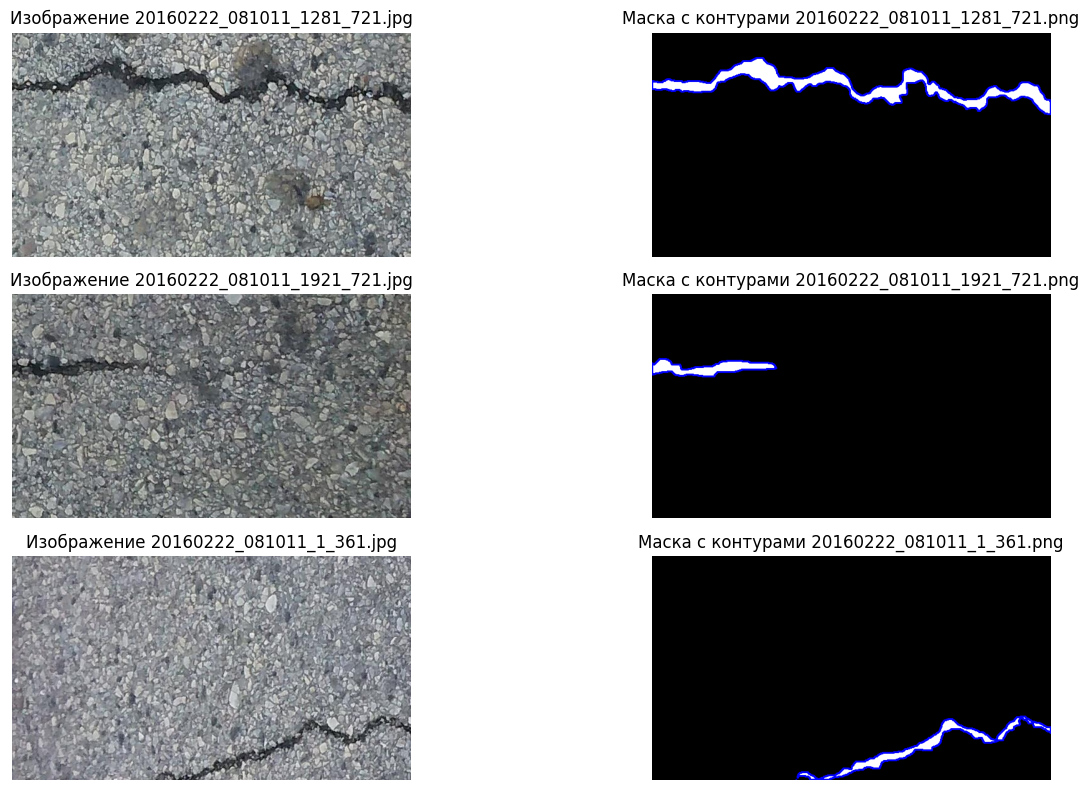

In [ ]:
plt.figure(figsize=(15, 8))
for i in range(3):
    img_path = os.path.join(train_images_dest, train_img_files[i])
    mask_path = os.path.join(train_masks_dest, train_mask_files[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if 255 in np.unique(mask):
        mask = mask // 255
    mask_contours = draw_contours_on_mask(mask)

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Изображение {train_img_files[i]}")
    plt.axis("off")

    plt.subplot(3, 2, 2*i+2)
    plt.imshow(mask_contours)
    plt.title(f"Маска с контурами {train_mask_files[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Общие выводы и мысли после EDA

* С учетом явного дисбаланса классов, при обучении модели следует рассмотреть использование специализированных функций потерь, таких как Dice Loss и др(об этом ниже), чтобы модель не «застревала» на предсказании фона.

* Также можно применять аугментации

# Обучение моделей, оценка и предсказания

Первая модель с Dice Loss на 50 эпохах

(Результаты на валидации радуют, но к сожалению произошёл печальный случай перезапуска коллаба и несохранения модельки (неудачный опыт - саммый ценный, выводы сделаны) )

In [11]:
results_dir = os.path.join(common_path, "results")
models_dir = os.path.join(results_dir, "models")
plots_dir  = os.path.join(results_dir, "plots")

In [ ]:
os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

In [12]:
class CrackDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, target_size=(512, 512)):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.mask_files  = sorted(os.listdir(masks_dir))
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        if 255 in np.unique(mask):
            mask = mask // 255

        image = np.transpose(image, (2, 0, 1)).astype(np.float32) / 255.0

        image_tensor = torch.from_numpy(image).float()
        mask_tensor = torch.from_numpy(mask).long()
        return image_tensor, mask_tensor

In [13]:
class UNetPlusPlusModel(nn.Module):
    def __init__(self, encoder_name="resnet34", encoder_weights="imagenet", classes=2):
        super(UNetPlusPlusModel, self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=classes
        )

    def forward(self, x):
        return self.model(x)

In [14]:
class Trainer:
    def __init__(self, model, device, train_loader, val_loader, optimizer, loss_variant="baseline"):
        self.model = model
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_variant = loss_variant
        self.loss_fn = self.get_loss_function(loss_variant)

    def get_loss_function(self, loss_variant):
        if loss_variant == "baseline":
            return smp.losses.DiceLoss(mode='multiclass')
        elif loss_variant == "tversky":
            return smp.losses.TverskyLoss(mode='multiclass', alpha=0.7, beta=0.3)
        elif loss_variant == "combined":
            class_weights = torch.tensor([0.53, 7.89], dtype=torch.float32).to(self.device)
            weighted_ce = nn.CrossEntropyLoss(weight=class_weights)
            dice_loss = smp.losses.DiceLoss(mode='multiclass')
            class CombinedLoss(nn.Module):
                def __init__(self, ce_loss, dice_loss, alpha=0.5):
                    super(CombinedLoss, self).__init__()
                    self.ce_loss = ce_loss
                    self.dice_loss = dice_loss
                    self.alpha = alpha
                def forward(self, outputs, targets):
                    return self.alpha * self.ce_loss(outputs, targets) + (1 - self.alpha) * self.dice_loss(outputs, targets)
            return CombinedLoss(weighted_ce, dice_loss, alpha=0.5)
        else:
            raise ValueError("Неизвестный вариант лосс-функции")

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for images, masks in tqdm(self.train_loader, desc="Training"):
            images = images.to(self.device)
            masks = masks.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, masks)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for images, masks in tqdm(self.val_loader, desc="Validation"):
                images = images.to(self.device)
                masks = masks.to(self.device)
                outputs = self.model(images)
                loss = self.loss_fn(outputs, masks)
                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds.cpu().numpy())
                all_trues.append(masks.cpu().numpy())
        return total_loss / len(self.val_loader), np.concatenate(all_trues, axis=0), np.concatenate(all_preds, axis=0)

In [14]:
train_dataset = CrackDataset(train_images_dest, train_masks_dest)
val_dataset = CrackDataset(val_images_dest, val_masks_dest)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = UNetPlusPlusModel().to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 332MB/s]


UNetPlusPlusModel(
  (model): UnetPlusPlus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      

In [17]:
loss_ch = "baseline"

In [18]:
if loss_ch == "baseline":
    loss_fn = smp.losses.DiceLoss(mode='multiclass')
elif loss_ch == "tversky":
    loss_fn = smp.losses.TverskyLoss(mode='multiclass', alpha=0.7, beta=0.3)
elif loss_ch == "combined":
    class_weights = torch.tensor([0.53, 7.89], dtype=torch.float32).to(device)
    weighted_ce = nn.CrossEntropyLoss(weight=class_weights)
    dice_loss = smp.losses.DiceLoss(mode='multiclass')
    class CombinedLoss(nn.Module):
        def __init__(self, ce_loss, dice_loss, alpha=0.5):
            super(CombinedLoss, self).__init__()
            self.ce_loss = ce_loss
            self.dice_loss = dice_loss
            self.alpha = alpha
        def forward(self, outputs, targets):
            return self.alpha * self.ce_loss(outputs, targets) + (1 - self.alpha) * self.dice_loss(outputs, targets)
    loss_fn = CombinedLoss(weighted_ce, dice_loss, alpha=0.5)
else:
    raise ValueError("Неизвестный вариант лосс-функции")

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
trainer = Trainer(model, device, train_loader, val_loader, optimizer, loss_fn)

In [16]:
class Evaluator:
    def __init__(self, plots_dir):
        self.plots_dir = plots_dir
        os.makedirs(self.plots_dir, exist_ok=True)

    def plot_loss_curve(self, train_losses, val_losses, filename="loss_curve.png"):
        plt.figure(figsize=(8,6))
        epochs = range(1, len(train_losses)+1)
        plt.plot(epochs, train_losses, label="Train Loss")
        plt.plot(epochs, val_losses, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss Curve")
        plt.legend()
        save_path = os.path.join(self.plots_dir, filename)
        plt.savefig(save_path)
        plt.close()
        print("Loss curve saved to:", save_path)

    def plot_lr_curve(self, lrs, filename="lr_curve.png"):
        plt.figure(figsize=(8,6))
        epochs = range(1, len(lrs)+1)
        plt.plot(epochs, lrs, label="Learning Rate")
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Schedule")
        plt.legend()
        save_path = os.path.join(self.plots_dir, filename)
        plt.savefig(save_path)
        plt.close()
        print("Learning rate curve saved to:", save_path)

    def plot_roc_curve(self, true_flat, prob_flat, filename="roc_curve.png"):
        fpr, tpr, _ = roc_curve(true_flat, prob_flat)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
        plt.plot([0,1], [0,1], 'r--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        save_path = os.path.join(self.plots_dir, filename)
        plt.savefig(save_path)
        plt.close()
        print("ROC curve saved to:", save_path)

    def plot_precision_recall_curve(self, true_flat, prob_flat, filename="precision_recall_curve.png"):
        precision, recall, _ = precision_recall_curve(true_flat, prob_flat)
        plt.figure(figsize=(8,6))
        plt.plot(recall, precision, label="Precision-Recall")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.legend()
        save_path = os.path.join(self.plots_dir, filename)
        plt.savefig(save_path)
        plt.close()
        print("Precision-Recall curve saved to:", save_path)

    def plot_penta_diagram(self, metrics, filename="penta_diagram.png"):
        labels = list(metrics.keys())
        values = list(metrics.values())
        num_vars = len(labels)
        angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
        ax.plot(angles, values, linewidth=2, linestyle='solid', label="Metrics")
        ax.fill(angles, values, alpha=0.25)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels)
        ax.set_title("Penta Diagram")
        ax.grid(True)
        save_path = os.path.join(self.plots_dir, filename)
        plt.savefig(save_path)
        plt.close()
        print("Penta Diagram saved to:", save_path)

In [17]:
def calculate_metrics(true_masks, pred_masks):
    true_flat = true_masks.flatten()
    pred_flat = pred_masks.flatten()
    TP = np.sum((true_flat == 1) & (pred_flat == 1))
    TN = np.sum((true_flat == 0) & (pred_flat == 0))
    FP = np.sum((true_flat == 0) & (pred_flat == 1))
    FN = np.sum((true_flat == 1) & (pred_flat == 0))
    accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    recall    = TP / (TP + FN + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    iou       = TP / (TP + FP + FN + 1e-6)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1, "iou": iou}

In [18]:
class Predictor:
    def __init__(self, model, device, predictions_dir, target_size=(512,512), threshold=0.5):
        self.model = model
        self.device = device
        self.predictions_dir = predictions_dir
        os.makedirs(self.predictions_dir, exist_ok=True)
        self.target_size = target_size
        self.threshold = threshold

    def predict_and_save(self, images_dir):
        test_img_files = sorted(os.listdir(images_dir))
        for img_file in test_img_files:
            img_path = os.path.join(images_dir, img_file)
            image = cv2.imread(img_path)
            if image is None:
                print("Не удалось прочитать:", img_path)
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            resized_img = cv2.resize(image_rgb, self.target_size)
            input_tensor = torch.from_numpy(np.transpose(resized_img, (2,0,1))).float().unsqueeze(0).to(self.device) / 255.0
            with torch.no_grad():
                outputs = self.model(input_tensor)
                probs = torch.softmax(outputs, dim=1)[:, 1, :, :].squeeze().cpu().numpy()
                pred_mask = (probs > self.threshold).astype(np.uint8)
            contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                conf = np.mean(probs[y:y+h, x:x+w])
                cv2.rectangle(resized_img, (x,y), (x+w, y+h), (255,0,0), 2)
                cv2.putText(resized_img, f"{conf:.2f}", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
            result_bgr = cv2.cvtColor(resized_img, cv2.COLOR_RGB2BGR)
            save_path = os.path.join(self.predictions_dir, img_file)
            cv2.imwrite(save_path, result_bgr)
            print(f"[{loss_variant}] Сохранено: {save_path}")

    def evaluate_mean_iou(self, images_dir, masks_dir):
        iou_sum = 0.0
        count = 0
        test_files = sorted(os.listdir(images_dir))
        for img_file in test_files:
            img_path = os.path.join(images_dir, img_file)
            mask_path = os.path.join(masks_dir, os.path.splitext(img_file)[0] + ".png")
            if not os.path.exists(mask_path):
                continue
            image = cv2.imread(img_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            resized_img = cv2.resize(image_rgb, self.target_size)
            input_tensor = torch.from_numpy(np.transpose(resized_img, (2,0,1))).float().unsqueeze(0).to(self.device) / 255.0
            with torch.no_grad():
                outputs = self.model(input_tensor)
                probs = torch.softmax(outputs, dim=1)[:, 1, :, :].squeeze().cpu().numpy()
                pred_mask = (probs > self.threshold).astype(np.uint8)
            true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            true_mask = cv2.resize(true_mask, self.target_size, interpolation=cv2.INTER_NEAREST)
            if 255 in np.unique(true_mask):
                true_mask = true_mask // 255
            true_flat = true_mask.flatten()
            pred_flat = pred_mask.flatten()
            TP = np.sum((true_flat==1) & (pred_flat==1))
            FP = np.sum((true_flat==0) & (pred_flat==1))
            FN = np.sum((true_flat==1) & (pred_flat==0))
            iou = TP / (TP + FP + FN + 1e-6)
            iou_sum += iou
            count += 1
        mean_iou = iou_sum / count if count > 0 else 0
        return mean_iou

In [19]:
def plot_loss_curve(self, train_losses, val_losses, filename="loss_curve.png"):
    plt.figure(figsize=(8,6))
    epochs = range(1, len(train_losses)+1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    save_path = os.path.join(self.plots_dir, filename)
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print("Loss curve saved to:", save_path)

In [ ]:
epochs = 50
best_iou = 0
train_losses = []
val_losses = []
lrs = []

In [ ]:
for epoch in range(1, epochs+1):
    train_loss = trainer.train_epoch()
    val_loss, true_masks, pred_masks = trainer.validate()
    metrics = calculate_metrics(true_masks, pred_masks)
    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(current_lr)
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {current_lr:.6f}")
    print("Validation Metrics:", metrics)
    if metrics["iou"] > best_iou:
      best_iou = metrics["iou"]
      save_model_path = os.path.join(models_dir, "best_model_baseline.pth")
      torch.save(model.state_dict(), save_model_path)
      print("Новая лучшая модель сохранена по пути:", save_model_path)
    scheduler.step()

Validation: 100%|██████████| 87/87 [01:55<00:00,  1.33s/it]


Epoch 1/50 - Train Loss: 0.1983 - Val Loss: 0.1597 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9702029831107899), 'precision': np.float64(0.7341511503189881), 'recall': np.float64(0.7484686966647272), 'f1': np.float64(0.7412402918144031), 'iou': np.float64(0.5888662318572703)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.21it/s]


Epoch 2/50 - Train Loss: 0.1574 - Val Loss: 0.2368 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9621807953406919), 'precision': np.float64(0.7848631869474976), 'recall': np.float64(0.4639063797031584), 'f1': np.float64(0.583138407234665), 'iou': np.float64(0.4115709462195692)}


Validation: 100%|██████████| 87/87 [00:17<00:00,  5.03it/s]


...

Epoch 48/50 - Train Loss: 0.0856 - Val Loss: 0.1242 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9779153253840197), 'precision': np.float64(0.814697085643313), 'recall': np.float64(0.7930753676914329), 'f1': np.float64(0.8037403396773026), 'iou': np.float64(0.6718785244736737)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.16it/s]


Epoch 49/50 - Train Loss: 0.0840 - Val Loss: 0.1247 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9774686659889553), 'precision': np.float64(0.801722725935251), 'recall': np.float64(0.8035981158748405), 'f1': np.float64(0.8026588254591565), 'iou': np.float64(0.6703683776260494)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.22it/s]


Epoch 50/50 - Train Loss: 0.0836 - Val Loss: 0.1257 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9774694113895704), 'precision': np.float64(0.8068852551113781), 'recall': np.float64(0.7951844542383786), 'f1': np.float64(0.8009916259927826), 'iou': np.float64(0.6680457595919687)}


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [ ]:
_, true_masks, pred_masks = trainer.validate()
final_metrics = calculate_metrics(true_masks, pred_masks)
print("Final metrics on validation set:", final_metrics)

Validation: 100%|██████████| 87/87 [00:17<00:00,  5.04it/s]


Final metrics on validation set: {'accuracy': np.float64(0.9783678493280413), 'precision': np.float64(0.8138360967197658), 'recall': np.float64(0.8047006235174194), 'f1': np.float64(0.8092420785539781), 'iou': np.float64(0.6796032205653736)}


In [ ]:
all_probs = []
all_trues = []

In [ ]:
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1, :, :].cpu().numpy()
        all_probs.append(probs.flatten())
        all_trues.append(masks.numpy().flatten())

In [ ]:
all_probs = np.concatenate(all_probs)
all_trues = np.concatenate(all_trues)

In [ ]:
plot_roc_curve(all_trues, all_probs, save_path="roc_curve.png")

<ipython-input-21-6514f0bd0f95>:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


In [ ]:
plot_precision_recall_curve(all_trues, all_probs, save_path="precision_recall_curve.png")

<ipython-input-22-6c4b3a10af61>:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


In [ ]:
plot_penta_diagram(final_metrics, save_path="penta_diagram.png")

ROC Curve:


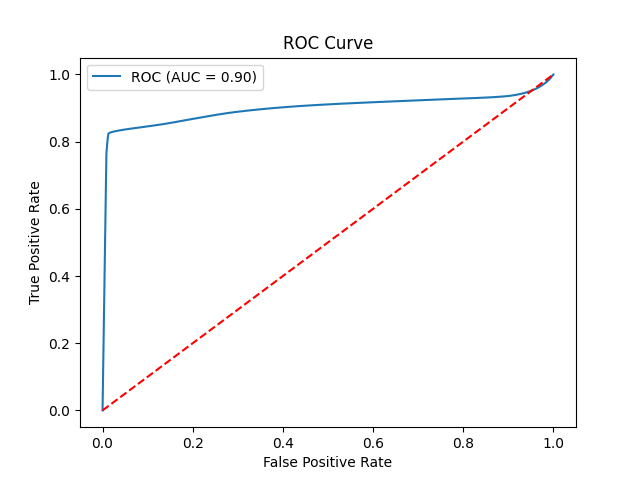

In [ ]:
print("ROC Curve:")
display(Image("roc_curve.png"))

Precision-Recall Curve:


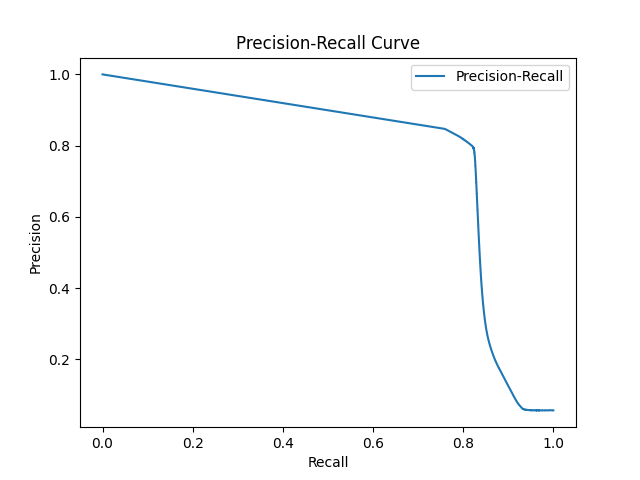

In [ ]:
print("Precision-Recall Curve:")
display(Image("precision_recall_curve.png"))

Penta Diagram:


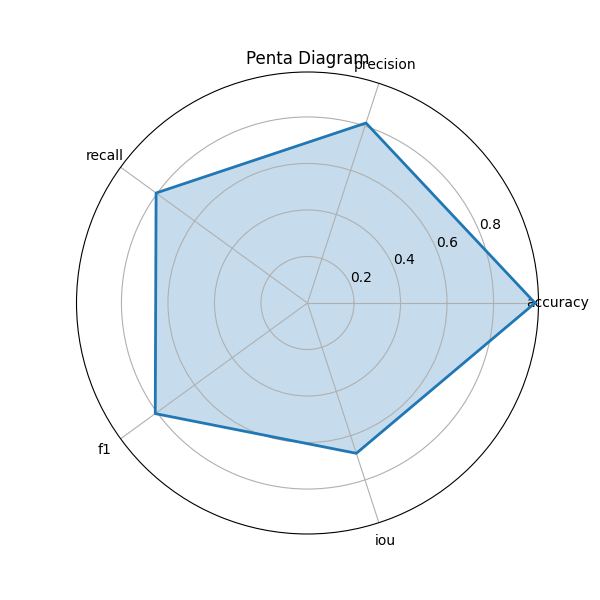

In [ ]:
print("Penta Diagram:")
display(Image("penta_diagram.png"))

эта моделька по моей глупой ошибке не была сохранена 😭 F

# Варианты используемых лоссов

Далее пробую другие варианты подсчета лосса, дабы улучшить результат


### 1. Dice Loss (модель выше)

### 2. Tversky loss

### 3. Combined Loss (Weighted CE + DiceLoss)



## Сводка теории по видам лосса

### 1. Dice Loss

Формула коэффициента Dice:

Dice = $\frac{2TP}{2TP + FP + FN}$

и лосс определяется как

$L_{Dice} = 1 - Dice$

Преимущества:

	•	Фокусируется на степени перекрытия между предсказанием и истиной.
	•	Менее чувствителен к дисбалансу, так как вычисляется на основе соотношения, а не абсолютных значений.

Недостатки:

	•	Может быть нестабилен при очень малых объектах, когда знаменатель становится очень маленьким.

### 2. Tversky loss

Формула Tversky коэффициента:

$ Tversky = \frac{TP}{TP + \alpha \cdot FP + \beta \cdot FN} $

и лосс может быть определён как

$ L_{Tversky} = 1 - Tversky $

Преимущества:

	•	Позволяет настраивать alpha и beta, чтобы сбалансировать штрафы за FP и FN.
	•	Для нашей задачи можно увеличить beta (например, установить alpha=0.7, beta=0.3), чтобы сильнее штрафовать пропуски трещин (FN).

Недостатки:

	•	Требует вдумчивой настройки параметров \alpha и \beta.

### 3. Combined Loss

Формула:

$ L = \alpha \cdot L_{CE} + (1 - \alpha) \cdot L_{Dice} $

Преимущества:

	•	Объединяет преимущества Weighted CE (точечное penalizing по пикселям) и Dice Loss (учет пространственного перекрытия).
	•	Даёт возможность сбалансировать между точностью пиксельной классификации и качеством сегментации.

Недостатки:

	•	Требует выбора коэффициента alpha (например, alpha=0.5)

### 4. Weighted Cross-Entropy Loss

Формула:

$ L_{CE} = -\sum_{c=1}^{C} w_c \cdot y_{c} \cdot \log(p_{c}) $
где:

$w_c$ — вес для класса c (например, можно установить $w_0$ = 0.53 для фона и $w_1$ = 7.89 для трещин).
$y_{c}$ — истинная метка (one-hot encoded).
$p_{c}$ — предсказанная вероятность для класса c.

Преимущества:
	•	Позволяет явно компенсировать дисбаланс, увеличивая вклад редкого класса (трещин).
	•	Хорош для пиксельной классификации.

Недостатки:
	•	Может быть чувствительна к шуму и не учитывать пространственное перекрытие.



## Резюмируя,

**Weighted CE** позволяет усилить вклад трещин за счет увеличения веса, но не учитывает пространственное перекрытие.

**Dice Loss** хорошо измеряет перекрытие, но при экстремальном дисбалансе может оказаться менее чувствительным к редким объектам.

**Tversky Loss** предоставляет гибкость за счёт настройки $\alpha$ и $\beta$ и можно сделать модель более чувствительной к пропущенным дефектам (FN).

**Combined Loss** объединяет оба подхода и может быть оптимальным выбором для нашей задачи, так как помогает и компенсировать дисбаланс, и улучшать пространственное совпадение сегментаций.

# Tversky Loss

In [ ]:
model2 = UNetPlusPlusModel().to(device)
print(model2)

In [ ]:
loss_variant = "tversky"
optimizer = optim.Adam(model2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
trainer = Trainer(model2, device, train_loader, val_loader, optimizer, loss_variant)

In [ ]:
epochs = 50
best_iou = 0
best_state = None
train_losses = []
val_losses = []
lrs = []

In [ ]:
models_dir = os.path.join(common_path, "results", "models")
os.makedirs(models_dir, exist_ok=True)
save_model_path = os.path.join(models_dir, "best_model_tversky.pth")

In [ ]:
for epoch in range(1, epochs+1):
    train_loss = trainer.train_epoch()
    val_loss, true_masks, pred_masks = trainer.validate()
    metrics = calculate_metrics(true_masks, pred_masks)
    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(current_lr)
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {current_lr:.6f}")
    print("Validation Metrics:", metrics)
    if metrics["iou"] > best_iou:
        best_iou = metrics["iou"]
        best_state = copy.deepcopy(model2.state_dict())
    scheduler.step()

Validation: 100%|██████████| 87/87 [00:17<00:00,  5.10it/s]


Epoch 1/50 - Train Loss: 0.1533 - Val Loss: 0.1651 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9699419284688909), 'precision': np.float64(0.8604979529691952), 'recall': np.float64(0.5643478056924836), 'f1': np.float64(0.6816454171074081), 'iou': np.float64(0.517043101837222)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.33it/s]


Epoch 2/50 - Train Loss: 0.1419 - Val Loss: 0.1422 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9728398049014632), 'precision': np.float64(0.8151138468712174), 'recall': np.float64(0.6773068746877169), 'f1': np.float64(0.7398474629039031), 'iou': np.float64(0.5871100743068541)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.37it/s]


...

Epoch 48/50 - Train Loss: 0.0844 - Val Loss: 0.1172 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9782252695368517), 'precision': np.float64(0.8487120656055602), 'recall': np.float64(0.7522122243585265), 'f1': np.float64(0.7975532583702261), 'iou': np.float64(0.6632760182835212)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.36it/s]


Epoch 49/50 - Train Loss: 0.0840 - Val Loss: 0.1180 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9780046638400969), 'precision': np.float64(0.8566045687200059), 'recall': np.float64(0.7377575513601815), 'f1': np.float64(0.7927510127944147), 'iou': np.float64(0.6566597652372169)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.34it/s]


Epoch 50/50 - Train Loss: 0.0840 - Val Loss: 0.1185 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9779439027281907), 'precision': np.float64(0.8589758884006603), 'recall': np.float64(0.7336379983919472), 'f1': np.float64(0.7913744329017661), 'iou': np.float64(0.6547728897240858)}


In [ ]:
if best_state is not None:
    final_model_path = os.path.join(models_dir, f"best_model_{loss_variant}.pth")
    torch.save(best_state, final_model_path)
    print("Лучшее состояние модели сохранено по пути:", final_model_path)

Лучшее состояние модели сохранено по пути: /content/drive/MyDrive/Colab Notebooks/Task2/results/models/best_model_tversky.pth


In [ ]:
model2.load_state_dict(torch.load(final_model_path))
_, true_masks, pred_masks = trainer.validate()
final_metrics = calculate_metrics(true_masks, pred_masks)
print("Final metrics on validation set:", final_metrics)

Validation: 100%|██████████| 87/87 [00:16<00:00,  5.29it/s]


Final metrics on validation set: {'accuracy': np.float64(0.9786882181277113), 'precision': np.float64(0.857275313006304), 'recall': np.float64(0.7513313716962255), 'f1': np.float64(0.800814074143189), 'iou': np.float64(0.6677987851240647)}


In [ ]:
evaluator = Evaluator(plots_dir)

In [ ]:
evaluator.plot_loss_curve(train_losses, val_losses, f"loss_curve_{loss_variant}.png")
evaluator.plot_lr_curve(lrs, f"lr_curve_{loss_variant}.png")

Loss curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_tversky.png
Learning rate curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_tversky.png


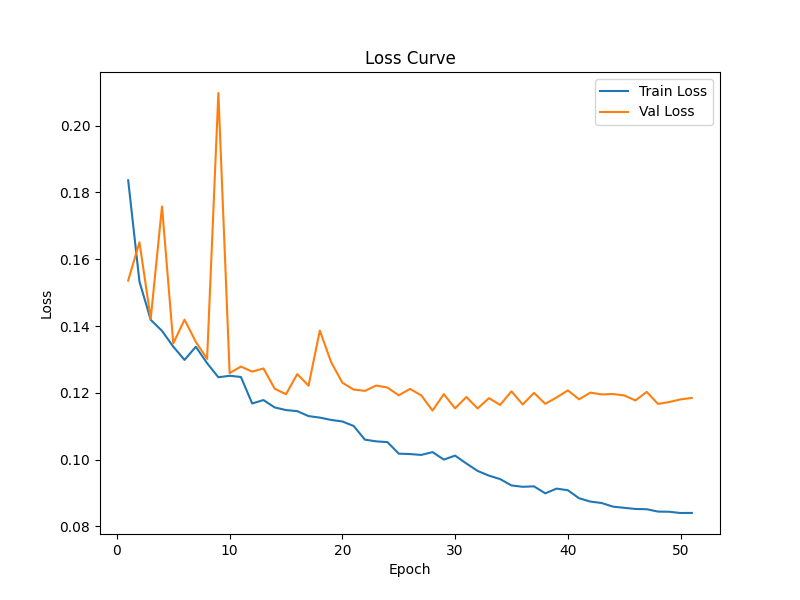

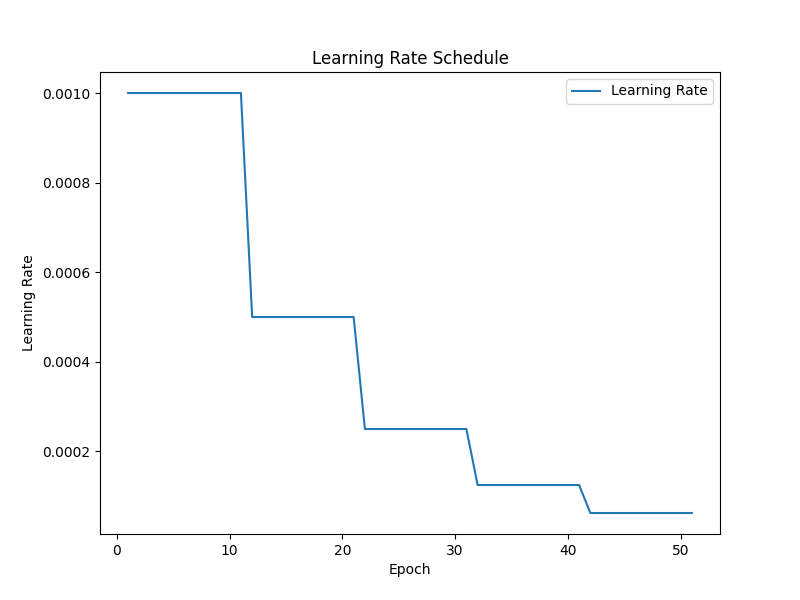

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_tversky.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_tversky.png"))

Лучшая эпоха -  27

*   IoU: 0.6664
*   Train Loss: 0.1000 Val Loss: 0.1147 (минимум!)
*   Accuracy: 0.9786 Precision: 0.8569 Recall: 0.7499 F1-score: 0.7998

  Val loss снижается примерно до эпохи 20, а затем колеблется, разница между train и val loss увеличивается, что говорит о легком переобучении.

Но переобучение не такое жёсткое, как у комбинированного loss’а

In [ ]:
all_probs = []
all_trues = []

In [ ]:
model2.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model2(images)
        probs = torch.softmax(outputs, dim=1)[:, 1, :, :].cpu().numpy()
        all_probs.append(probs.flatten())
        all_trues.append(masks.numpy().flatten())

In [ ]:
all_probs = np.concatenate(all_probs)
all_trues = np.concatenate(all_trues)
evaluator.plot_roc_curve(all_trues, all_probs, f"roc_curve_{loss_variant}.png")
evaluator.plot_precision_recall_curve(all_trues, all_probs, f"precision_recall_curve_{loss_variant}.png")
evaluator.plot_penta_diagram(final_metrics, f"penta_diagram_{loss_variant}.png")

<ipython-input-52-baa4ef1e8d6b>:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


ROC curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_tversky.png


<ipython-input-52-baa4ef1e8d6b>:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


Precision-Recall curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_tversky.png
Penta Diagram saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_tversky.png


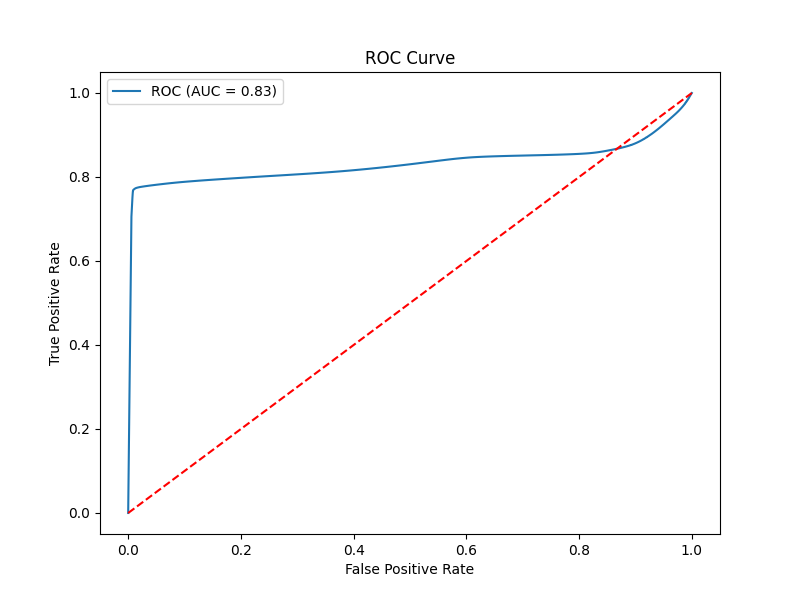

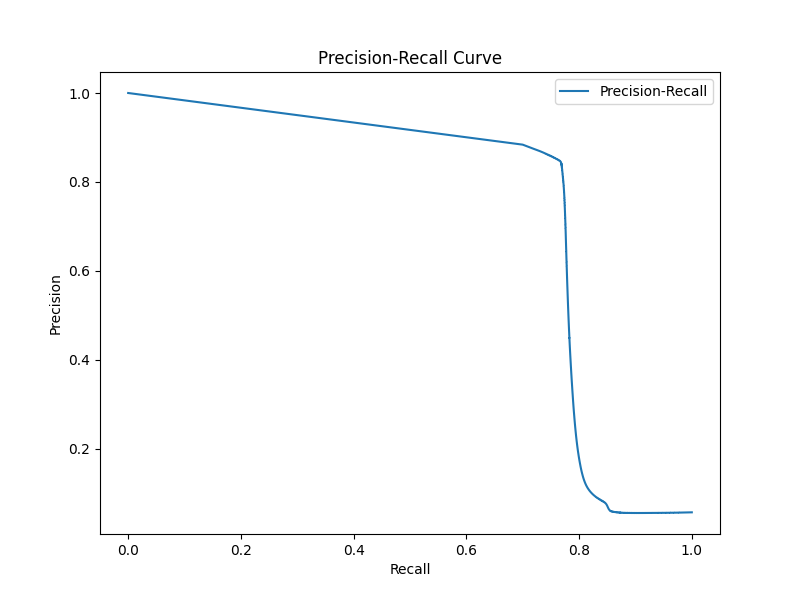

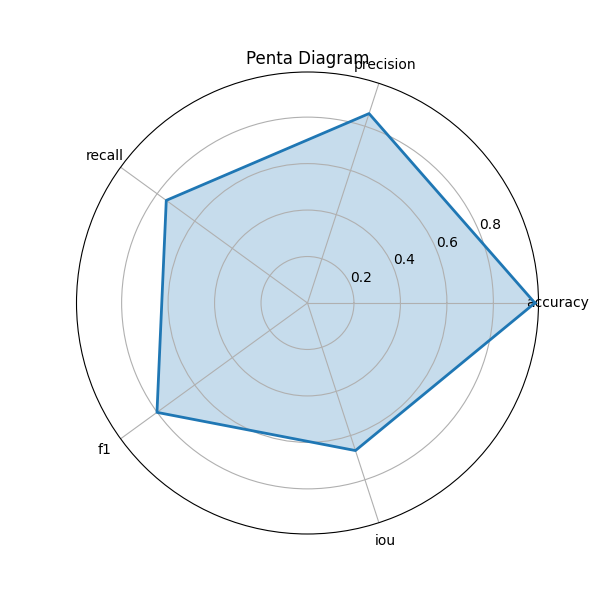

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_tversky.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_tversky.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_tversky.png"))

In [ ]:
test_predictions_dir = os.path.join(os.path.dirname(test_images_dest), "predictions", loss_variant)
os.makedirs(test_predictions_dir, exist_ok=True)

In [ ]:
predictor = Predictor(model2, device, test_predictions_dir, target_size=(512,512), threshold=0.5)
predictor.predict_and_save(test_images_dest)

In [ ]:
if os.path.exists(test_masks_dest):
    mean_iou_test = predictor.evaluate_mean_iou(test_images_dest, test_masks_dest)
    mean_iou_path = os.path.join(test_predictions_dir, "mean_iou.txt")
    with open(mean_iou_path, "w") as f:
        f.write(f"Mean IoU on test set: {mean_iou_test:.4f}\n")
    print("Mean IoU сохранено по пути:", mean_iou_path)

Mean IoU сохранено по пути: /content/drive/MyDrive/Colab Notebooks/Task2/data/test/predictions/tversky/mean_iou.txt


# Combined Loss

А теперь пробуем Combined Loss

In [ ]:
model3 = UNetPlusPlusModel().to(device)
print(model3)

In [ ]:
loss_variant = "combined"
optimizer = optim.Adam(model3.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
trainer = Trainer(model3, device, train_loader, val_loader, optimizer, loss_variant)

In [ ]:
epochs = 50
best_iou = 0
best_state = None
train_losses = []
val_losses = []
lrs = []

In [ ]:
for epoch in range(1, epochs+1):
    train_loss = trainer.train_epoch()
    val_loss, true_masks, pred_masks = trainer.validate()
    metrics = calculate_metrics(true_masks, pred_masks)
    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(current_lr)
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {current_lr:.6f}")
    print("Validation Metrics:", metrics)
    if metrics["iou"] > best_iou:
        best_iou = metrics["iou"]
        best_state = copy.deepcopy(model3.state_dict())
    scheduler.step()

Validation: 100%|██████████| 87/87 [00:18<00:00,  4.80it/s]


Epoch 1/50 - Train Loss: 0.2973 - Val Loss: 0.3488 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.8762908694387757), 'precision': np.float64(0.301386057598146), 'recall': np.float64(0.887362744046192), 'f1': np.float64(0.44994961718205106), 'iou': np.float64(0.2902809550901951)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.28it/s]


Epoch 2/50 - Train Loss: 0.2461 - Val Loss: 0.2376 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9164969345618839), 'precision': np.float64(0.40030495957528495), 'recall': np.float64(0.9324194535020656), 'f1': np.float64(0.5601335848762573), 'iou': np.float64(0.3890181497299273)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.35it/s]


...

Epoch 48/50 - Train Loss: 0.0525 - Val Loss: 0.3273 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9752046760471281), 'precision': np.float64(0.7523761481545561), 'recall': np.float64(0.8424075383453806), 'f1': np.float64(0.7948500436979636), 'iou': np.float64(0.6595452015487272)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.33it/s]


Epoch 49/50 - Train Loss: 0.0517 - Val Loss: 0.3395 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9750223379025408), 'precision': np.float64(0.7515109172709014), 'recall': np.float64(0.8395560133475823), 'f1': np.float64(0.7930968848651032), 'iou': np.float64(0.6571345296478787)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.35it/s]


Epoch 50/50 - Train Loss: 0.0511 - Val Loss: 0.3352 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9750935565466061), 'precision': np.float64(0.7506502262101479), 'recall': np.float64(0.8433443334181421), 'f1': np.float64(0.7943016037020827), 'iou': np.float64(0.6587903183175844)}


In [ ]:
if best_state is not None:
    final_model_path = os.path.join(models_dir, f"best_model_{loss_variant}.pth")
    torch.save(best_state, final_model_path)
    print("Лучшая модель по пути:", final_model_path)

Лучшая модель по пути: /content/drive/MyDrive/Colab Notebooks/Task2/results/models/best_model_combined.pth


In [ ]:
model3.load_state_dict(torch.load(final_model_path))
_, true_masks, pred_masks = trainer.validate()
final_metrics = calculate_metrics(true_masks, pred_masks)
print("Final metrics on validation set:", final_metrics)

Validation: 100%|██████████| 87/87 [00:17<00:00,  5.08it/s]


Final metrics on validation set: {'accuracy': np.float64(0.9753705167222191), 'precision': np.float64(0.7550849061228203), 'recall': np.float64(0.8407673299397166), 'f1': np.float64(0.7956254448122537), 'iou': np.float64(0.6606136515405997)}


In [ ]:
evaluator = Evaluator(plots_dir)
evaluator.plot_loss_curve(train_losses, val_losses, f"loss_curve_{loss_variant}.png")
evaluator.plot_lr_curve(lrs, f"lr_curve_{loss_variant}.png")

Loss curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_combined.png
Learning rate curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_combined.png


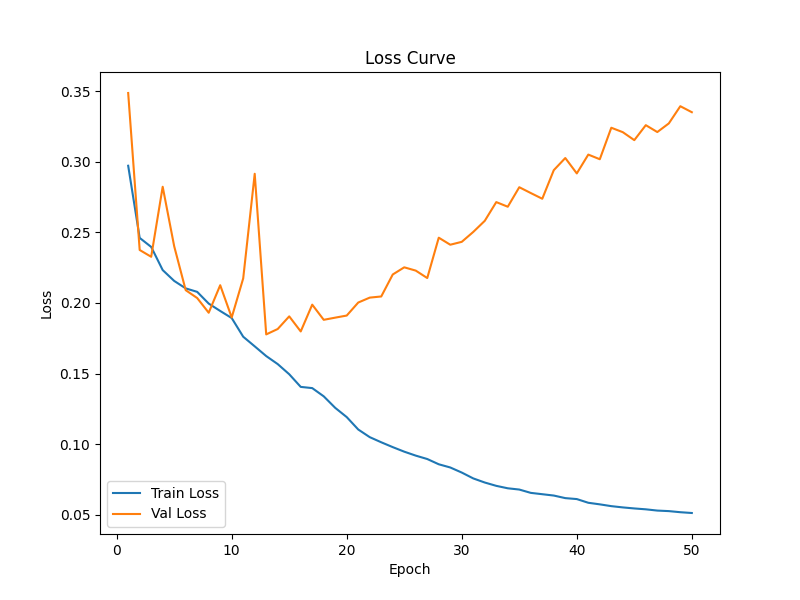

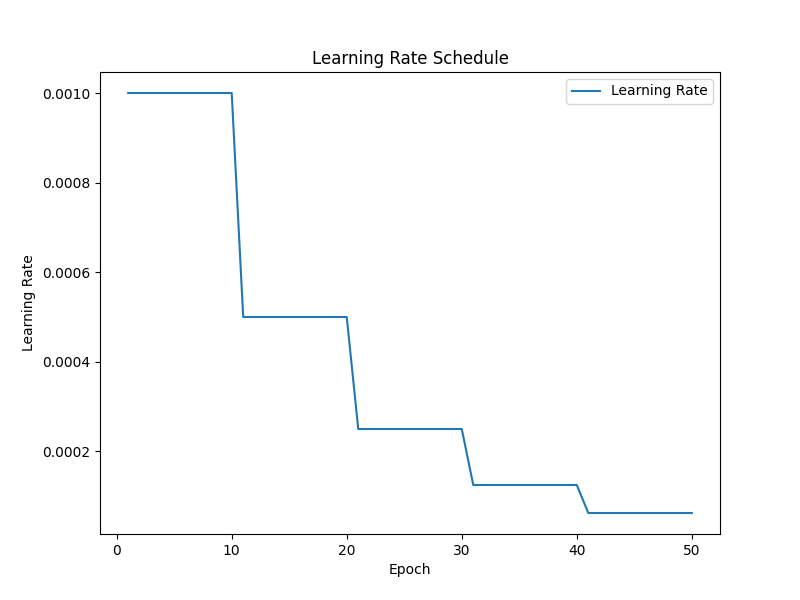

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_combined.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_combined.png"))

Видим СИЛЬНОЕ переобучение - Val loss после начального снижения начинает активно расти.	Наилучшая точка валидации примерно на эпохах ~20-25 (0.20-0.22), затем loss растёт до ~0.33

Наилучшая эпоха для Combined Loss - на 46-й эпохе с  IoU 0.6606, accuracy 97.54%, precision 0.7551 и recall 0.8407. Потом метрики падают

In [ ]:
all_probs = []
all_trues = []
model3.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model3(images)
        probs = torch.softmax(outputs, dim=1)[:, 1, :, :].cpu().numpy()
        all_probs.append(probs.flatten())
        all_trues.append(masks.numpy().flatten())
all_probs = np.concatenate(all_probs)
all_trues = np.concatenate(all_trues)
evaluator.plot_roc_curve(all_trues, all_probs, f"roc_curve_{loss_variant}.png")
evaluator.plot_precision_recall_curve(all_trues, all_probs, f"precision_recall_curve_{loss_variant}.png")
evaluator.plot_penta_diagram(final_metrics, f"penta_diagram_{loss_variant}.png")

<ipython-input-52-baa4ef1e8d6b>:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


ROC curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_combined.png


<ipython-input-52-baa4ef1e8d6b>:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


Precision-Recall curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_combined.png
Penta Diagram saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_combined.png


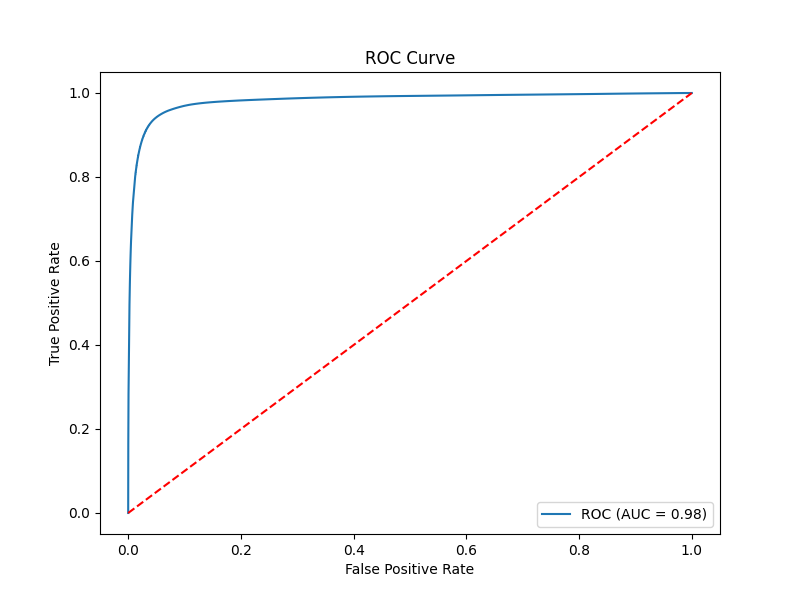

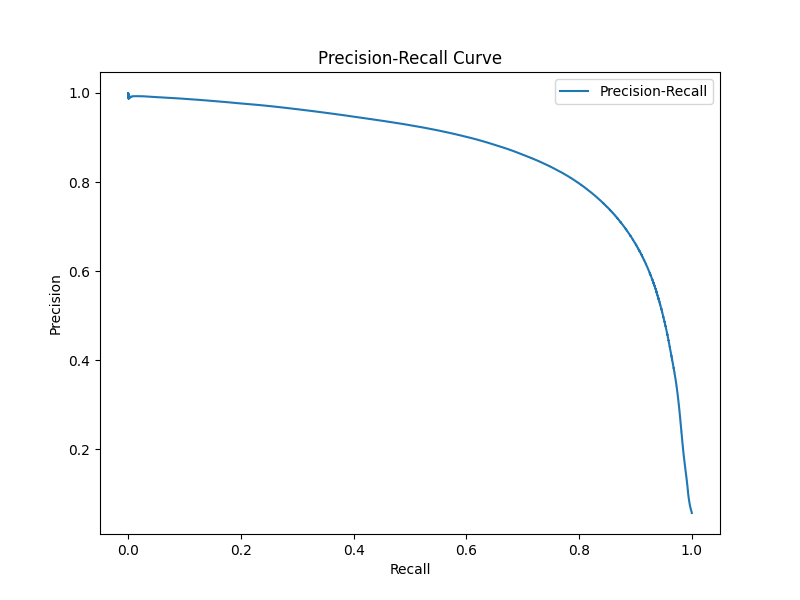

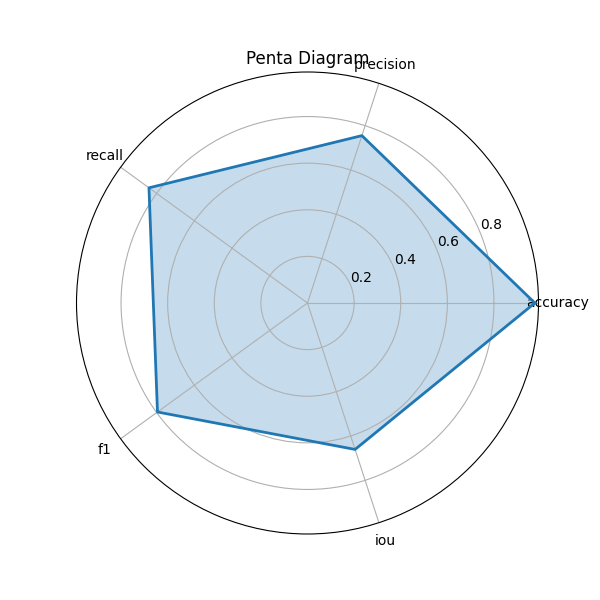

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_combined.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_combined.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_combined.png"))

In [ ]:
test_predictions_dir = os.path.join(os.path.dirname(test_images_dest), "predictions", loss_variant)
os.makedirs(test_predictions_dir, exist_ok=True)
predictor = Predictor(model3, device, test_predictions_dir, target_size=(512,512), threshold=0.5)
predictor.predict_and_save(test_images_dest)

In [ ]:
if os.path.exists(test_masks_dest):
    mean_iou_test = predictor.evaluate_mean_iou(test_images_dest, test_masks_dest)
    mean_iou_path = os.path.join(test_predictions_dir, "mean_iou.txt")
    with open(mean_iou_path, "w") as f:
        f.write(f"Mean IoU on test set: {mean_iou_test:.4f}\n")
    print("Mean IoU сохранено по пути:", mean_iou_path)

Mean IoU сохранено по пути: /content/drive/MyDrive/Colab Notebooks/Task2/data/test/predictions/combined/mean_iou.txt


# Dice Loss

Теперь еще 1 последняя попытка обучения с dice loss

In [ ]:
model0 = UNetPlusPlusModel().to(device)
print(model0)

In [ ]:
loss_variant = "baseline"
optimizer = optim.Adam(model0.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
trainer = Trainer(model0, device, train_loader, val_loader, optimizer, loss_variant)

In [ ]:
epochs = 50
best_iou = 0
best_state = None
train_losses = []
val_losses = []
lrs = []

In [ ]:
for epoch in range(1, epochs+1):
    train_loss = trainer.train_epoch()
    val_loss, true_masks, pred_masks = trainer.validate()
    metrics = calculate_metrics(true_masks, pred_masks)
    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(current_lr)
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {current_lr:.6f}")
    print("Validation Metrics:", metrics)
    if metrics["iou"] > best_iou:
        best_iou = metrics["iou"]
        best_state = copy.deepcopy(model0.state_dict())
    scheduler.step()

Validation: 100%|██████████| 87/87 [00:16<00:00,  5.43it/s]


Epoch 1/50 - Train Loss: 0.1925 - Val Loss: 0.1625 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9698075700080152), 'precision': np.float64(0.7389045049658723), 'recall': np.float64(0.727602562046914), 'f1': np.float64(0.7332094831449542), 'iou': np.float64(0.5787936227330892)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.32it/s]


Epoch 2/50 - Train Loss: 0.1574 - Val Loss: 0.1421 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9734193538797207), 'precision': np.float64(0.7638939387228187), 'recall': np.float64(0.772656772357303), 'f1': np.float64(0.7682498686646594), 'iou': np.float64(0.6237065951503352)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.27it/s]


...

Epoch 48/50 - Train Loss: 0.0837 - Val Loss: 0.1258 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9754591645865498), 'precision': np.float64(0.7724516958961815), 'recall': np.float64(0.8074833258934142), 'f1': np.float64(0.7895786359598833), 'iou': np.float64(0.6523178499401233)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.25it/s]


Epoch 49/50 - Train Loss: 0.0836 - Val Loss: 0.1273 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.975130793692041), 'precision': np.float64(0.768570614934952), 'recall': np.float64(0.8067964453691013), 'f1': np.float64(0.7872192610341299), 'iou': np.float64(0.6491033867929025)}


Validation: 100%|██████████| 87/87 [00:16<00:00,  5.37it/s]


Epoch 50/50 - Train Loss: 0.0824 - Val Loss: 0.1320 - LR: 0.000063
Validation Metrics: {'accuracy': np.float64(0.9722986440548845), 'precision': np.float64(0.7304218317988659), 'recall': np.float64(0.8149705735229733), 'f1': np.float64(0.770382864486021), 'iou': np.float64(0.6265232104064126)}


In [ ]:
if best_state is not None:
    final_model_path = os.path.join(models_dir, f"best_model_{loss_variant}.pth")
    torch.save(best_state, final_model_path)
    print("Лучшая модель по пути:", final_model_path)

Лучшая модель по пути: /content/drive/MyDrive/Colab Notebooks/Task2/results/models/best_model_baseline.pth


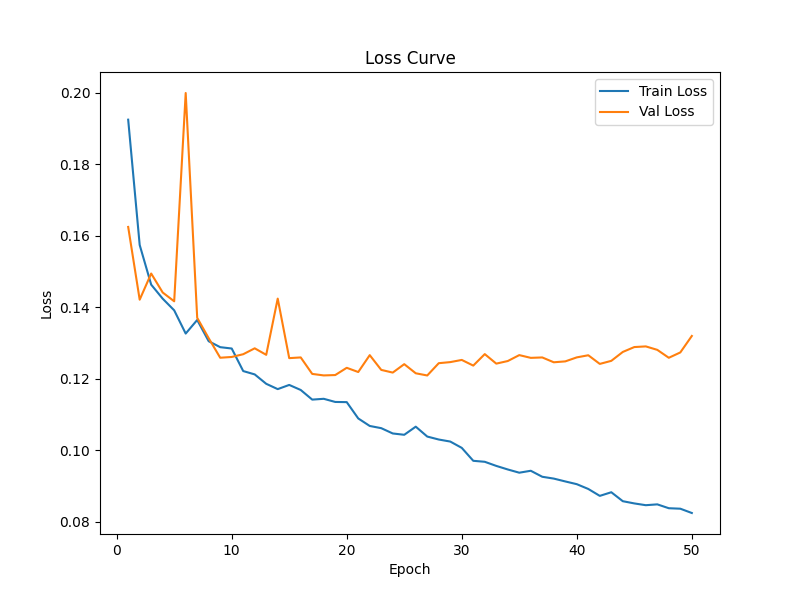

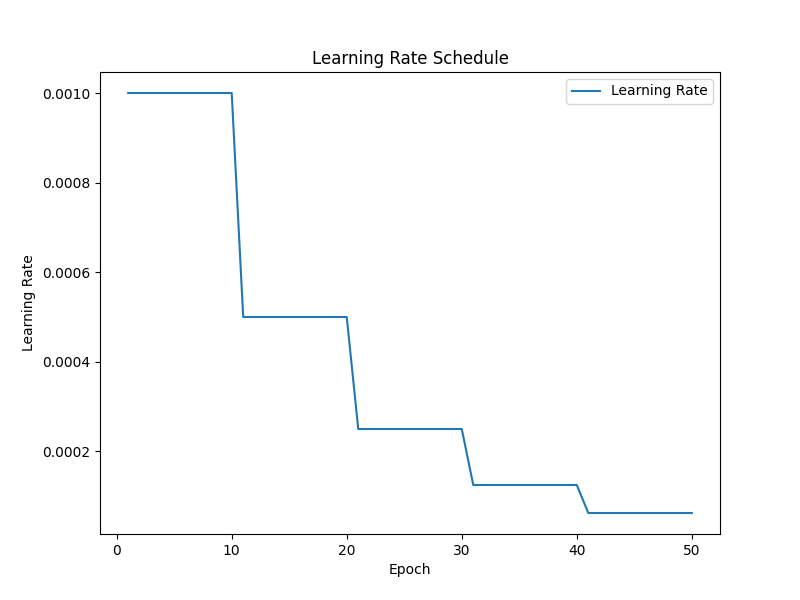

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_baseline.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_baseline.png"))

Видим переобучение с 28 эпохи

  лучший IoU был 0.6810,  а Accuracy - 97.84%

In [ ]:
model0.load_state_dict(torch.load(final_model_path))
_, true_masks, pred_masks = trainer.validate()
final_metrics = calculate_metrics(true_masks, pred_masks)
print("Final metrics on validation set:", final_metrics)

Validation: 100%|██████████| 87/87 [00:16<00:00,  5.27it/s]


Final metrics on validation set: {'accuracy': np.float64(0.9785082148409331), 'precision': np.float64(0.8158320720834308), 'recall': np.float64(0.8047556047180782), 'f1': np.float64(0.8102554854495239), 'iou': np.float64(0.6810338824995166)}


In [ ]:
evaluator = Evaluator(plots_dir)
evaluator.plot_loss_curve(train_losses, val_losses, f"loss_curve_{loss_variant}.png")
evaluator.plot_lr_curve(lrs, f"lr_curve_{loss_variant}.png")

Loss curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_baseline.png
Learning rate curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_baseline.png


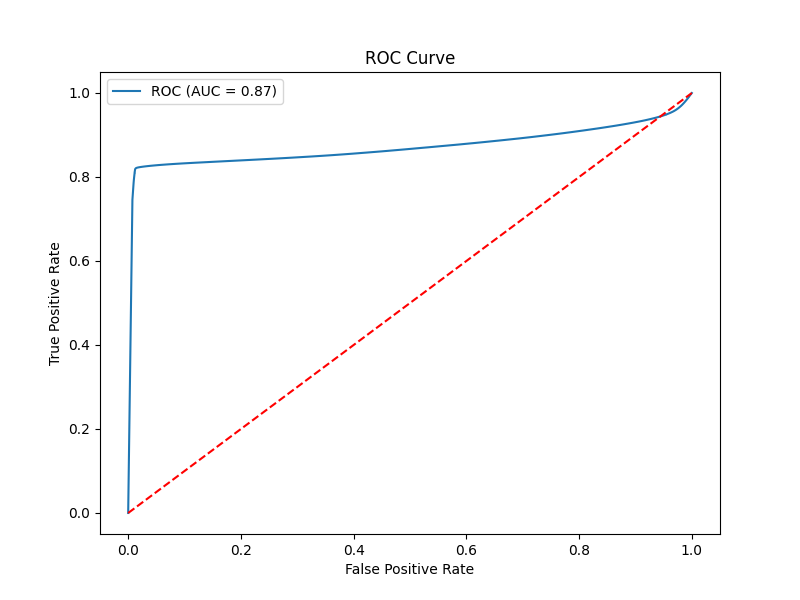

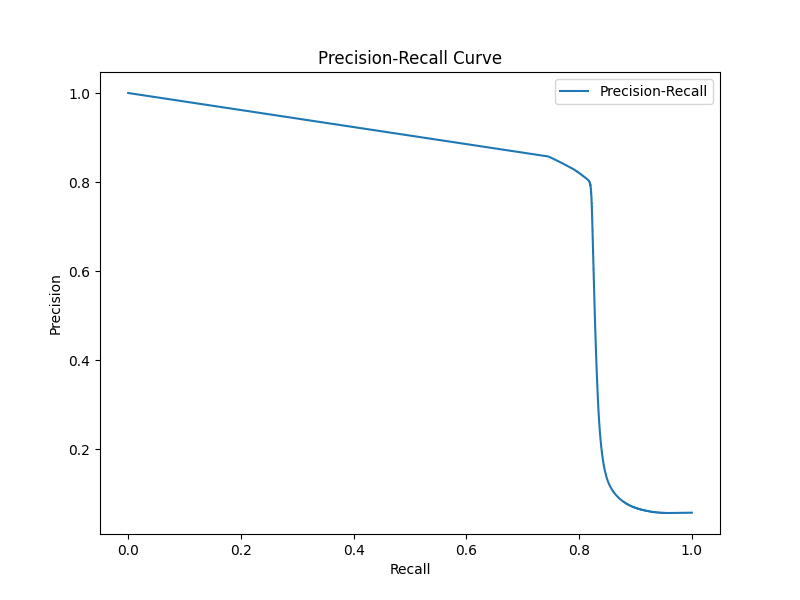

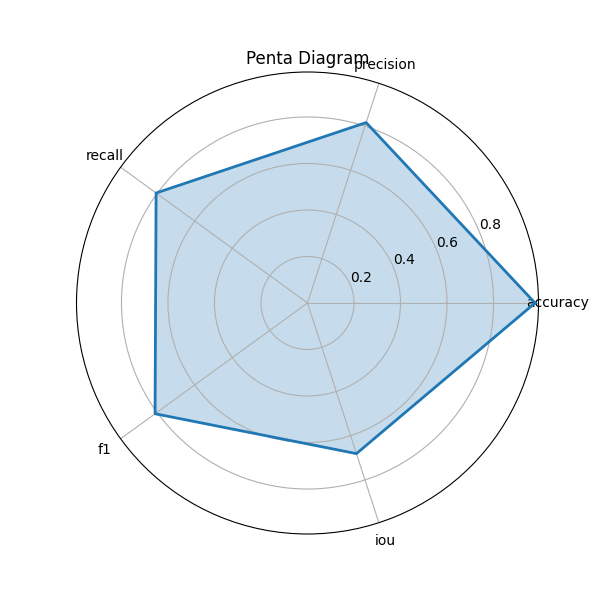

In [ ]:
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_baseline.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_baseline.png"))
display(Image("/content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_baseline.png"))

In [ ]:
all_probs = []
all_trues = []
model0.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model0(images)
        probs = torch.softmax(outputs, dim=1)[:, 1, :, :].cpu().numpy()
        all_probs.append(probs.flatten())
        all_trues.append(masks.numpy().flatten())
all_probs = np.concatenate(all_probs)
all_trues = np.concatenate(all_trues)
evaluator.plot_roc_curve(all_trues, all_probs, f"roc_curve_{loss_variant}.png")
evaluator.plot_precision_recall_curve(all_trues, all_probs, f"precision_recall_curve_{loss_variant}.png")
evaluator.plot_penta_diagram(final_metrics, f"penta_diagram_{loss_variant}.png")

<ipython-input-52-baa4ef1e8d6b>:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


ROC curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_baseline.png


<ipython-input-52-baa4ef1e8d6b>:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


Precision-Recall curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_baseline.png
Penta Diagram saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_baseline.png


In [ ]:
test_predictions_dir = os.path.join(os.path.dirname(test_images_dest), "predictions", loss_variant)
os.makedirs(test_predictions_dir, exist_ok=True)
predictor = Predictor(model0, device, test_predictions_dir, target_size=(512,512), threshold=0.5)
predictor.predict_and_save(test_images_dest)

In [ ]:
if os.path.exists(test_masks_dest):
    mean_iou_test = predictor.evaluate_mean_iou(test_images_dest, test_masks_dest)
    mean_iou_path = os.path.join(test_predictions_dir, "mean_iou.txt")
    with open(mean_iou_path, "w") as f:
        f.write(f"Mean IoU on test set: {mean_iou_test:.4f}\n")
    print("Mean IoU сохранено по пути:", mean_iou_path)

Mean IoU сохранено по пути: /content/drive/MyDrive/Colab Notebooks/Task2/data/test/predictions/baseline/mean_iou.txt


# Итоговое сравнение моделей (3 варианта лосса)

СРАВНЕНИЕ ПО ЛУЧШИМ ЭПОХАМ

In [58]:
metrics_ls = {
    "Dice Loss": 0.6810,
    "Tversky Loss": 0.6664,
    "Combined Loss": 0.6606
}

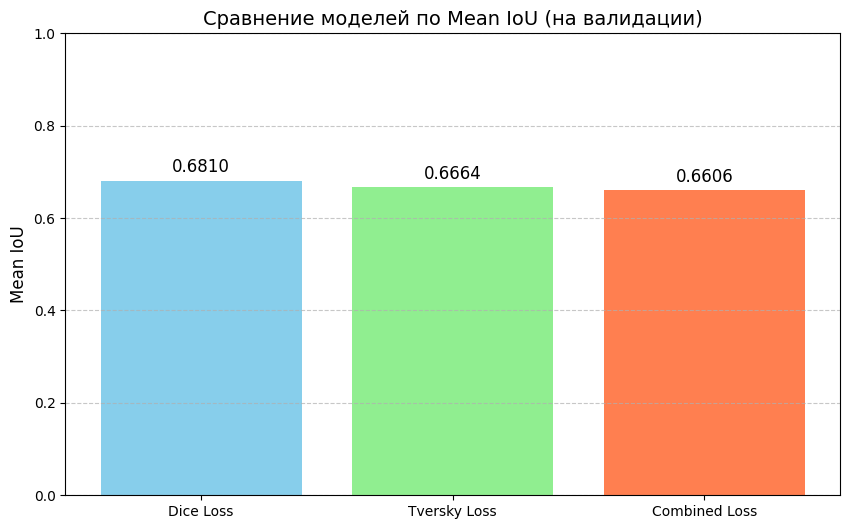

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(metrics_ls.keys(), metrics_ls.values(), color=['skyblue', 'lightgreen', 'coral'])
ax.set_ylim(0, 1)
ax.set_ylabel("Mean IoU", fontsize=12)
ax.set_title("Сравнение моделей по Mean IoU (на валидации)", fontsize=14)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.4f}",
            ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

In [60]:
plt.savefig("mean_iou_comparison.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [62]:
print("Сравнительные результаты:")
for loss, iou in metrics_ls.items():
    print(f"Loss: {loss:<8} | Mean IoU: {iou:.4f}")

Сравнительные результаты:
Loss: Dice Loss | Mean IoU: 0.6810
Loss: Tversky Loss | Mean IoU: 0.6664
Loss: Combined Loss | Mean IoU: 0.6606


In [65]:
best_model = max(metrics_ls, key=metrics_ls.get)
print(f"\nЛучшая модель по Mean IoU: {best_model.upper()} Loss")


Лучшая модель по Mean IoU: DICE LOSS Loss


# Дальнейшие планы по заданию:

* откорректировать число эпох и предотвратить переобучение
* возможно усилить дропаут
* попробовать аугментации
* early stopping

In [ ]:
pip install albumentations

In [21]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [22]:
def compute_mean_std(image_dir):
    means = []
    stds = []
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]

    for fname in tqdm(image_files, desc="Computing mean/std"):
        img = cv2.imread(os.path.join(image_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0
        means.append(np.mean(img, axis=(0,1)))
        stds.append(np.std(img, axis=(0,1)))

    mean = np.mean(means, axis=0)
    std = np.mean(stds, axis=0)
    return mean, std

In [ ]:
train_img_path = "/content/drive/MyDrive/Colab Notebooks/Task2/data/train/images"
mean, std = compute_mean_std(train_img_path)
print("Mean:", mean)
print("Std:", std)

In [24]:
mean_tr = [0.49403492, 0.4960782, 0.4970601]
std_tr = [0.1600704,  0.15913214, 0.1557644 ]

обновим CrackDataset - добавим аугментации

In [25]:
class CrackDataset(Dataset):
    def __init__(self, images_dir, masks_dir, is_train=True, target_size=(512, 512), mean=None, std=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.mask_files  = sorted(os.listdir(masks_dir))
        self.target_size = target_size
        self.is_train = is_train
        self.mean = mean_tr
        self.std = std_tr
        self.transform = self.get_transform()

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if 255 in np.unique(mask):
            mask = mask // 255

        augmented = self.transform(image=image, mask=mask)
        image, mask = augmented["image"], augmented["mask"]
        image = image.astype(np.float32) / 255.0
        image = (image - self.mean) / self.std
        image = np.transpose(image, (2, 0, 1))

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

    def get_transform(self):
        if self.is_train:
            return A.Compose([
                A.Resize(*self.target_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Affine(scale=(0.95, 1.05),
                  translate_percent=(0.05, 0.05),
                  rotate=(-10, 10),
                  interpolation=cv2.INTER_LINEAR,
                  mask_interpolation=cv2.INTER_NEAREST,
                  p=0.5),
                A.RandomBrightnessContrast(p=0.3),
            ])
        else:
            return A.Compose([
                A.Resize(*self.target_size),
            ])

In [26]:
train_dataset = CrackDataset(train_images_dest, train_masks_dest)
val_dataset = CrackDataset(val_images_dest, val_masks_dest)

In [27]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

добавим EarlyStopping и ReduceLR для борьбы с переобучением

In [28]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [29]:
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping: {self.counter} / {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Saving new best model with val_loss {val_loss:.4f}')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [30]:
class Trainer:
    def __init__(self, model, device, train_loader, val_loader, optimizer, scheduler=None, early_stopping=None, loss_variant="baseline"):
        self.model = model
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.early_stopping = early_stopping
        self.loss_variant = loss_variant
        self.loss_fn = self.get_loss_function(loss_variant)

    def get_loss_function(self, loss_variant):
        if loss_variant == "baseline":
            return smp.losses.DiceLoss(mode='multiclass')
        elif loss_variant == "tversky":
            return smp.losses.TverskyLoss(mode='multiclass', alpha=0.7, beta=0.3)
        elif loss_variant == "combined":
            class_weights = torch.tensor([0.53, 7.89], dtype=torch.float32).to(self.device)
            weighted_ce = nn.CrossEntropyLoss(weight=class_weights)
            dice_loss = smp.losses.DiceLoss(mode='multiclass')
            class CombinedLoss(nn.Module):
                def __init__(self, ce_loss, dice_loss, alpha=0.5):
                    super(CombinedLoss, self).__init__()
                    self.ce_loss = ce_loss
                    self.dice_loss = dice_loss
                    self.alpha = alpha
                def forward(self, outputs, targets):
                    return self.alpha * self.ce_loss(outputs, targets) + (1 - self.alpha) * self.dice_loss(outputs, targets)
            return CombinedLoss(weighted_ce, dice_loss, alpha=0.5)
        else:
            raise ValueError("Неизвестный вариант лосс-функции")

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for images, masks in tqdm(self.train_loader, desc="Training"):
            images = images.to(self.device)
            masks = masks.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, masks)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_trues = []
        with torch.no_grad():
            for images, masks in tqdm(self.val_loader, desc="Validation"):
                images = images.to(self.device)
                masks = masks.to(self.device)
                outputs = self.model(images)
                loss = self.loss_fn(outputs, masks)
                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds.cpu().numpy())
                all_trues.append(masks.cpu().numpy())
        avg_val_loss = total_loss / len(self.val_loader)
        if self.scheduler:
            self.scheduler.step(avg_val_loss)
        if self.early_stopping:
            self.early_stopping(avg_val_loss, self.model)
        return avg_val_loss, np.concatenate(all_trues, axis=0), np.concatenate(all_preds, axis=0)

    def should_stop(self):
        return self.early_stopping.early_stop if self.early_stopping else False

In [31]:
model_X = UNetPlusPlusModel().to(device)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 174MB/s]


In [32]:
loss_variant1 = "baseline"

In [33]:
optimizer = optim.Adam(model_X.parameters(), lr=1e-3, weight_decay=1e-4)

In [34]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [35]:
early_stopper = EarlyStopping(patience=10, verbose=True, path=os.path.join(models_dir, f"best_model_{loss_variant1}.pth"))

In [36]:
trainer = Trainer(
    model=model_X,
    device=device,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    early_stopping=early_stopper,
    loss_variant="baseline"
)

In [37]:
epochs = 50
train_losses, val_losses, lrs = [], [], []

In [38]:
for epoch in range(1, epochs + 1):
    train_loss = trainer.train_epoch()
    val_loss, true_masks, pred_masks = trainer.validate()

    metrics = calculate_metrics(true_masks, pred_masks)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(current_lr)

    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {current_lr:.6f}")
    print("Validation Metrics:", metrics)

    if early_stopper.early_stop:
        print("Early stopping triggered. Training finished.")
        break

Validation: 100%|██████████| 87/87 [04:52<00:00,  3.36s/it]


Saving new best model with val_loss 0.3029
Epoch 1/50 - Train Loss: 0.2538 - Val Loss: 0.3029 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9579234178038745), 'precision': np.float64(0.800092953482384), 'recall': np.float64(0.3087660635497102), 'f1': np.float64(0.4455775263352595), 'iou': np.float64(0.2866518278686514)}


Validation: 100%|██████████| 87/87 [00:23<00:00,  3.76it/s]


Saving new best model with val_loss 0.2264
Epoch 2/50 - Train Loss: 0.1936 - Val Loss: 0.2264 - LR: 0.001000
Validation Metrics: {'accuracy': np.float64(0.9521061360150814), 'precision': np.float64(0.5500952685732148), 'recall': np.float64(0.6074255735829638), 'f1': np.float64(0.5773401794577548), 'iou': np.float64(0.40581794207265737)}


Validation: 100%|██████████| 87/87 [00:22<00:00,  3.82it/s]


...

EarlyStopping: 8 / 10
Epoch 27/50 - Train Loss: 0.1359 - Val Loss: 0.1526 - LR: 0.000500
Validation Metrics: {'accuracy': np.float64(0.9640913667349874), 'precision': np.float64(0.6313648004032683), 'recall': np.float64(0.8109380176436658), 'f1': np.float64(0.7099720783410617), 'iou': np.float64(0.5503546315405539)}


Validation: 100%|██████████| 87/87 [00:22<00:00,  3.89it/s]


EarlyStopping: 9 / 10
Epoch 28/50 - Train Loss: 0.1374 - Val Loss: 0.1684 - LR: 0.000500
Validation Metrics: {'accuracy': np.float64(0.9602995905382775), 'precision': np.float64(0.6028438532008014), 'recall': np.float64(0.7881063277574286), 'f1': np.float64(0.6831369236552512), 'iou': np.float64(0.5187613517574877)}


Validation: 100%|██████████| 87/87 [00:22<00:00,  3.92it/s]


EarlyStopping: 10 / 10
Epoch 29/50 - Train Loss: 0.1381 - Val Loss: 0.1728 - LR: 0.000500
Validation Metrics: {'accuracy': np.float64(0.9499801328812418), 'precision': np.float64(0.5225028711953197), 'recall': np.float64(0.8138347995068346), 'f1': np.float64(0.6364120544346124), 'iou': np.float64(0.4667192570958552)}
Early stopping triggered. Training finished.


In [ ]:
final_model_path = os.path.join(models_dir, f"best_model_{loss_variant1}(2).pth")
model_X.load_state_dict(torch.load(final_model_path))

In [42]:
_, true_masks, pred_masks = trainer.validate()
final_metrics = calculate_metrics(true_masks, pred_masks)

Validation: 100%|██████████| 87/87 [00:22<00:00,  3.84it/s]


Saving new best model with val_loss 0.1409


In [43]:
print("Final metrics on validation set:", final_metrics)

Final metrics on validation set: {'accuracy': np.float64(0.9744399169395603), 'precision': np.float64(0.7435177419922452), 'recall': np.float64(0.8061809680051377), 'f1': np.float64(0.773581938618695), 'iou': np.float64(0.630765949252896)}


In [47]:
evaluator.plot_loss_curve(train_losses, val_losses, f"loss_curve_{loss_variant1}(2).png")
evaluator.plot_lr_curve(lrs, f"lr_curve_{loss_variant1}(2).png")

Loss curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/loss_curve_baseline(2).png
Learning rate curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/lr_curve_baseline(2).png


In [54]:
model_X.eval()
all_probs = []
all_trues = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        outputs = model_X(images)
        probs = torch.softmax(outputs, dim=1)[:, 1, :, :].cpu().numpy()
        all_probs.append(probs.flatten())
        all_trues.append(masks.cpu().numpy().flatten())

all_probs = np.concatenate(all_probs)
all_trues = np.concatenate(all_trues)

In [56]:
with open(os.path.join(plots_dir, f"mean_iou(bl2).txt"), "w") as f:
    f.write(f"mean IoU: {final_metrics['iou']}\n")

evaluator.plot_roc_curve(all_trues, all_probs, f"roc_curve_{loss_variant1}(2).png")
evaluator.plot_precision_recall_curve(all_trues, all_probs, f"precision_recall_curve_{loss_variant1}(2).png")
evaluator.plot_penta_diagram(final_metrics, f"penta_diagram_{loss_variant1}(2).png")

ROC curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/roc_curve_baseline(2).png
Precision-Recall curve saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/precision_recall_curve_baseline(2).png
Penta Diagram saved to: /content/drive/MyDrive/Colab Notebooks/Task2/results/plots/penta_diagram_baseline(2).png


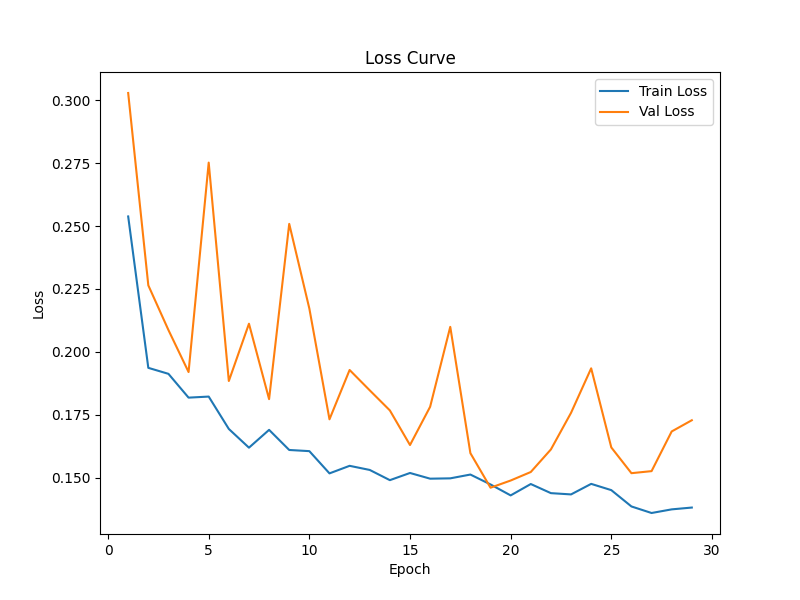

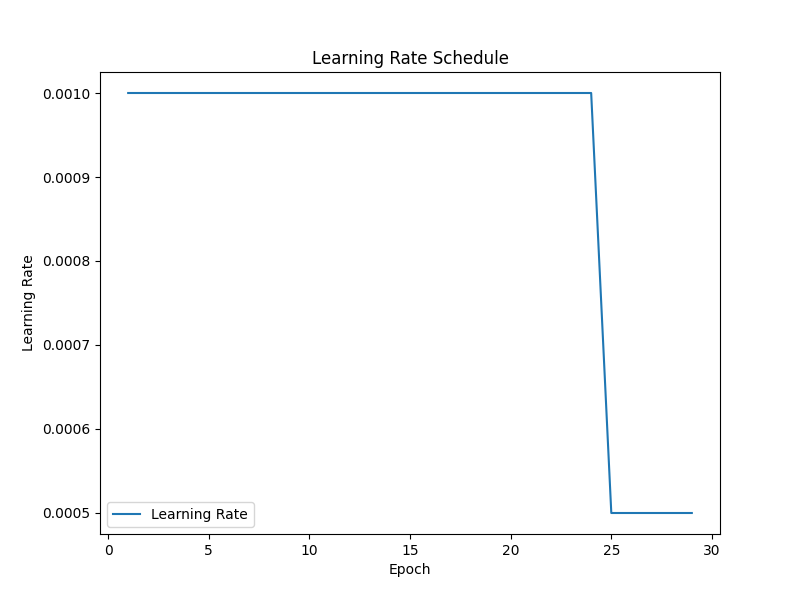

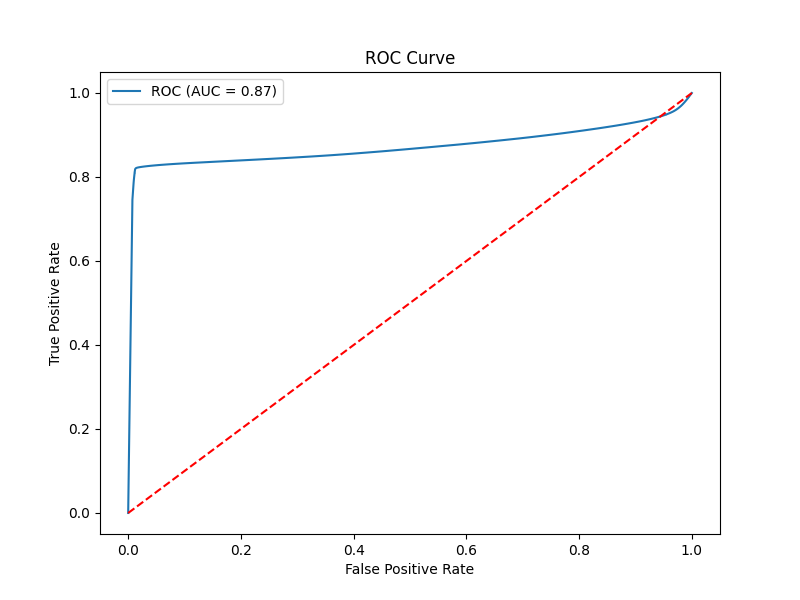

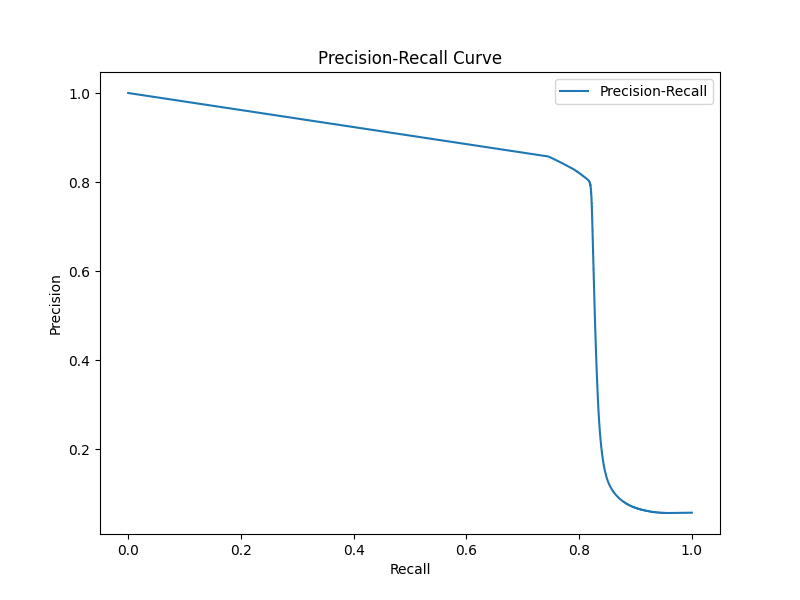

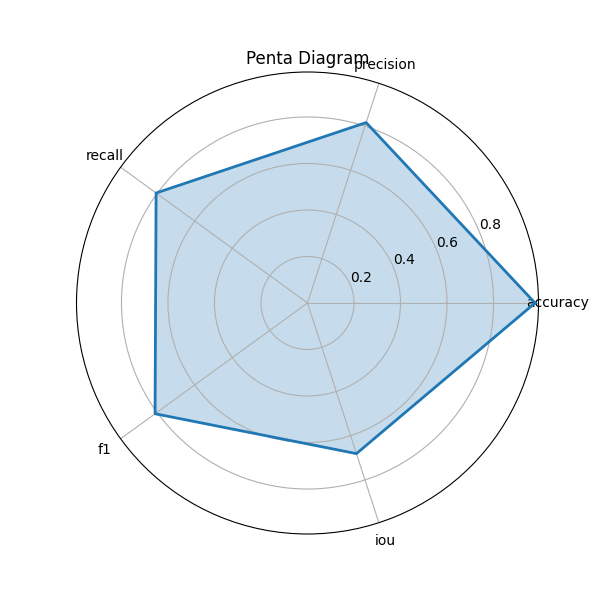

In [57]:
display(Image(os.path.join(plots_dir, f"loss_curve_{loss_variant1}(2).png")))
display(Image(os.path.join(plots_dir, f"lr_curve_{loss_variant1}(2).png")))
display(Image(os.path.join(plots_dir, f"roc_curve_{loss_variant1}(2).png")))
display(Image(os.path.join(plots_dir, f"precision_recall_curve_{loss_variant1}(2).png")))
display(Image(os.path.join(plots_dir, f"penta_diagram_{loss_variant1}(2).png")))

Лучшая эпоха — 19

Val Loss: 0.1460
Метрики:
	•	Accuracy: 0.9720
	•	Precision: 0.7192
	•	Recall: 0.7982
	•	F1-score: 0.7566
	•	IoU: 0.6085

Изменения в обучении:

	*	добавлены аугментации
	*	 новый шедулер (ReduceLROnPlateau)
	*	early stopping

Результат:

Метрики ухудшились. Возможные причины:

	*	агрессивные аугментации исказили форму трещин
	*	ранняя остановка обучения помешала достичь лучшего результата
	*	scheduler преждевременно снизил learning rate, замедлив обучение